# ReLU Glitch Experiment 

## 1. Imports & notebook

In [1]:
import os
import sys
import time
import json
import struct
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chipwhisperer as cw
from chipwhisperer.capture.api.programmers import STM32FProgrammer

plt.rcParams['figure.figsize'] = (12, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
np.set_printoptions(suppress=True, precision=5)

print('python', sys.version.split()[0])
print('numpy ', np.__version__)
print('pandas', pd.__version__)
print('cw', cw.__version__)

python 3.10.11
numpy  1.26.4
pandas 2.3.3
cw     6.0.0


## 2. Main configuration 

In [2]:
RECOMMENDED_BUILD = (
    r'make PLATFORM=CWLITEARM CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1 '
    r'ACTIVATION=relu EXPERIMENT=1 EXP_RELU_REPEAT=32'
)

FW_DIR = r'C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all'
FW_RELU_HEX = r'C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-relu-CWLITEARM.hex'

MNIST_CACHE = r'D:\mnist_cache'
RESULTS_ROOT = Path('results_relu_only')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

ACT_RELU = 0
ACT_SIGMOID = 1
ACT_TANH = 2
ACT_RELU_EXT = 3

FAULT_NONE = 0
FAULT_SKIP_NEURON = 1
FAULT_ZERO_NEURON = 2
FAULT_KEEP_PREV = 3
FAULT_PARTIAL_WIN = 4
FAULT_EARLY_TERM = 5
FAULT_PERTURB = 6

FAULT_NAMES = {
    FAULT_NONE:'NONE',
    FAULT_SKIP_NEURON:'SKIP_NEURON',
    FAULT_ZERO_NEURON:'ZERO_NEURON',
    FAULT_KEEP_PREV:'KEEP_PREV',
    FAULT_PARTIAL_WIN:'PARTIAL_WIN',
    FAULT_EARLY_TERM:'EARLY_TERM',
    FAULT_PERTURB:'PERTURB',
}

TRIGMODE_FULL = 0
TRIGMODE_WINDOW = 1
TRIGMODE_FULL_NETWORK = 2

TRIGGER_MODE_NAMES = {
    TRIGMODE_FULL: 'FULL',
    TRIGMODE_WINDOW: 'WINDOW',
    TRIGMODE_FULL_NETWORK: 'FULL_NETWORK',
}

CLKGEN_FREQ = 7_370_000
ADC_SAMPLES = 5000
ADC_OFFSET  = 0

DEFAULT_GLITCH_WIDTH      = 2.5
DEFAULT_GLITCH_OFFSET     = 10.0
DEFAULT_GLITCH_EXT_OFFSET = 500
DEFAULT_GLITCH_REPEAT     = 1

# 10 images x 3 widths x 2 offsets x 20 ext_offsets x 4 windows x 2 reps = 9600
FAST_WIDTHS     = (1.5, 2.5, 3.0)
FAST_OFFSETS    = (10.0, 25.0)
FAST_EXT_N      = 20
FAST_REPS       = 2
FAST_IMAGES_PER_CLASS = 1

FINE_REPS = 3

EXT_OFFSET_MIN = 50
EXT_OFFSET_MAX = 2500

DEFAULT_WINDOW_START = 24
DEFAULT_WINDOW_STOP  = 40

WINDOW_SWEEP_RANGES = [
    (16, 24),
    (24, 32),
    (32, 40),
    (40, 48),
]

WINDOW_STEP = 8
WINDOW_SIZE = 8

LOGIT_L1_EFFECT_THRESHOLD = 1e-3
LOGIT_MAXABS_EFFECT_THRESHOLD = 5e-4
Z1_DRIFT_OK_THRESHOLD = 5e-2

UART_TIMEOUT_MS = 2000
MAX_CONSEC_ERRORS = 4
MAX_TOTAL_BAD_FRACTION = 0.30
PING_TIMEOUT_MS = 800
BOOT_WAIT_S = 0.60
RESET_LOW_S = 0.05
POST_GLITCH_SETTLE_S = 0.20
HARD_RECOVERY_TRIES = 2

INPUT_BYTES = 784
UPLOAD_CHUNK_BYTES = 48
UPLOAD_FRAME_BYTES = 49
N_CHUNKS = (INPUT_BYTES + UPLOAD_CHUNK_BYTES - 1) // UPLOAD_CHUNK_BYTES
LOGITS_BYTES = 40
STATUS_BYTES = 16
HIDDEN_BYTES = 128
SNAP_CHUNK_BYTES = 32     
SNAP_CHUNKS_F32_64 = 8 # 64 float32 values = 256 bytes = 8 x 32-byte chunks
RELU_SUMMARY_BYTES = 32
LOGIT_ABS_SANITY_LIMIT = 1000.0
NN_HID = 64
NN_OUT = 10
 
N_IMAGES = 10 * FAST_IMAGES_PER_CLASS
COARSE_TRIALS = (
    N_IMAGES
    * len(FAST_WIDTHS)
    * len(FAST_OFFSETS)
    * FAST_EXT_N
    * len(WINDOW_SWEEP_RANGES)
    * FAST_REPS
)

print(f'firmware   : {FW_RELU_HEX}')
print(f'results dir: {RESULTS_ROOT.resolve()}')
print(f'window sweep ranges: {WINDOW_SWEEP_RANGES}')
print('recommended build:', RECOMMENDED_BUILD)

print()
print('--- coarse sweep plan ---')
print(f'images      : {N_IMAGES}')
print(f'widths      : {FAST_WIDTHS}')
print(f'offsets     : {FAST_OFFSETS}')
print(f'ext count   : {FAST_EXT_N}')
print(f'reps        : {FAST_REPS}')
print(f'windows     : {len(WINDOW_SWEEP_RANGES)}')
print(f'coarse total: {COARSE_TRIALS}')

print()
print('--- fine sweep plan ---')
print(f'FINE_REPS   : {FINE_REPS}')
print('recommended fine ext_deltas: (-60, -30, 0, 30, 60)')
print(f'post-glitch settle: {POST_GLITCH_SETTLE_S}s')
print(f'snapshot chunk size: {SNAP_CHUNK_BYTES} bytes')
print('snapshot commands: W=chunk32, V=relu_summary, Y=baseline_z_hi')


firmware   : C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-relu-CWLITEARM.hex
results dir: C:\Users\Admin\chipwhisperer\results_relu_only
window sweep ranges: [(16, 24), (24, 32), (32, 40), (40, 48)]
recommended build: make PLATFORM=CWLITEARM CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1 ACTIVATION=relu EXPERIMENT=1 EXP_RELU_REPEAT=32

--- coarse sweep plan ---
images      : 10
widths      : (1.5, 2.5, 3.0)
offsets     : (10.0, 25.0)
ext count   : 20
reps        : 2
windows     : 4
coarse total: 9600

--- fine sweep plan ---
FINE_REPS   : 3
recommended fine ext_deltas: (-60, -30, 0, 30, 60)
post-glitch settle: 0.2s
snapshot chunk size: 32 bytes
snapshot commands: W=chunk32, V=relu_summary, Y=baseline_z_hi


## 3. Scope setup

In [3]:
def setup_scope():
    scope = cw.scope()
    scope.default_setup()
    scope.clock.clkgen_freq = CLKGEN_FREQ

    scope.glitch.clk_src = 'clkgen'
    scope.glitch.output = 'clock_xor'
    scope.glitch.trigger_src = 'ext_single'
    scope.glitch.repeat = DEFAULT_GLITCH_REPEAT
    scope.glitch.width = DEFAULT_GLITCH_WIDTH
    scope.glitch.offset = DEFAULT_GLITCH_OFFSET
    scope.glitch.ext_offset = DEFAULT_GLITCH_EXT_OFFSET

    scope.adc.samples = ADC_SAMPLES
    scope.adc.offset = ADC_OFFSET
    scope.adc.basic_mode = 'rising_edge'

    scope.io.hs2 = 'clkgen'   # start in clean state
    return scope

scope = setup_scope()
print('scope ready')
print(f' clkgen_freq : {scope.clock.clkgen_freq}')
print(f' glitch.output : {scope.glitch.output}')
print(f' glitch.trigger_src: {scope.glitch.trigger_src}')
print(f' glitch.width : {scope.glitch.width}')
print(f' glitch.offset : {scope.glitch.offset}')
print(f' glitch.ext_offset: {scope.glitch.ext_offset}')
print(f' hs2 : {scope.io.hs2}')

(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.64.0) is outdated - latest is 0.65.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 2320992                   to 30898362                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

## 4. Transport layer (SimpleSerial 2.1)

Thin wrappers around `target.simpleserial_*`. `ss_read_exact(n)` takes only the
byte count — it internally reads the `'r'` response that firmware emits for
every command. `resync_target()` recovers after a crash/timeout without a full reflash.

In [4]:
class SnapshotReadError(RuntimeError):
    pass


def flush_target():
    try:
        target.flush()
    except Exception:
        pass


def ss_write(cmd, payload=b''):
    payload = bytearray(payload if payload is not None else b'')
    target.simpleserial_write(cmd, payload)


def _extract_payload(resp):
    if resp is None:
        raise RuntimeError('simpleserial_read returned None')
    if isinstance(resp, tuple):
        data = resp[0]
    elif isinstance(resp, dict) and 'payload' in resp:
        data = resp['payload']
    else:
        data = resp
    if data is None:
        raise RuntimeError('simpleserial payload is None')
    return bytearray(data)


def ss_read_exact(n, timeout=UART_TIMEOUT_MS):
    resp = target.simpleserial_read('r', n, timeout=timeout)
    data = _extract_payload(resp)
    if len(data) != n:
        raise RuntimeError(f'Expected {n} bytes, got {len(data)}: {list(data)[:16]}...')
    return data


def reset_target(reset_low_s=RESET_LOW_S, boot_wait_s=BOOT_WAIT_S):
    scope.io.hs2 = 'clkgen'
    flush_target()
    scope.io.nrst = 'low'
    time.sleep(reset_low_s)
    scope.io.nrst = 'high_z'
    time.sleep(boot_wait_s)
    flush_target()


def ping():
    try:
        ss_write('z', b'')
        raw = ss_read_exact(4, timeout=PING_TIMEOUT_MS)
        return raw == bytearray(b'\xde\xad\xbe\xef')
    except Exception:
        return False


def soft_resync_target(max_tries=3, verbose=False):
    """RX-only resync that does NOT reset the MCU, so g_last/g_baseline survive."""
    scope.io.hs2 = 'clkgen'
    last = None

    for k in range(max_tries):
        try:
            flush_target()
            time.sleep(0.02)
            if ping():
                if verbose:
                    print(f'  soft resync OK try {k+1}')
                return True
            raise RuntimeError('ping failed')
        except Exception as e:
            last = e
            flush_target()
            time.sleep(0.02)

    raise RuntimeError(f'soft resync failed: {last}')


def resync_target(max_tries=3, verbose=False):
    scope.io.hs2 = 'clkgen'
    last = None

    for phase in ('soft', 'hard'):
        for k in range(max_tries):
            try:
                flush_target()
                time.sleep(0.10 if phase == 'soft' else 0.20)
                if phase == 'hard':
                    reset_target()
                if ping():
                    if verbose:
                        print(f'  resync OK [{phase}] try {k+1}')
                    return True
                raise RuntimeError('ping failed')
            except Exception as e:
                last = e
                flush_target()
                time.sleep(0.10)

    raise RuntimeError(f'resync failed: {last}')


print('transport helpers ready')

transport helpers ready


In [5]:
# ---------- Atomic result packet (48 bytes) ----------
PACKET_BYTES         = 48
PACKET_MAGIC0        = 0xA5
PACKET_MAGIC1        = 0x5A
PACKET_KIND_BASELINE = 0
PACKET_KIND_INFER    = 1

PACKET_FLAG_INPUT_READY   = 0x01
PACKET_FLAG_HAVE_BASELINE = 0x02
PACKET_FLAG_HAVE_LAST     = 0x04
PACKET_FLAG_FAULT_ACTIVE  = 0x08


def cmd_clear():
    ss_write('c', b'')
    return ss_read_exact(2)


def cmd_status():
    ss_write('s', b'')
    raw = ss_read_exact(STATUS_BYTES)
    snapshot_flags = int(raw[15])
    return {
        'raw':                 raw,
        'act_type':            int(raw[0]),
        'fault_model':         int(raw[1]),
        'fault_target_neuron': int(raw[2]),
        'fault_window_stop':   int(raw[3]),
        'input_ready':         int(raw[4]),
        'have_baseline':       int(raw[5]),
        'have_last':           int(raw[6]),
        'baseline_pred':       int(raw[7]),
        'last_pred':           int(raw[8]),
        'loaded':              int(raw[9] | (raw[10] << 8)),
        'seq':                 int(raw[11]),
        'trigger_mode':        int(raw[12]),
        'trigger_start':       int(raw[13]),
        'trigger_stop':        int(raw[14]),
        '_reserved':           snapshot_flags,
        'have_baseline_a1':    bool(snapshot_flags & 0x01),
        'have_baseline_z1':    bool(snapshot_flags & 0x02),
        'have_last_a1':        bool(snapshot_flags & 0x04),
        'have_last_z1':        bool(snapshot_flags & 0x08),
    }


def cmd_set_activation(act_type):
    ss_write('a', bytes([act_type & 0xFF]))
    return int(ss_read_exact(1)[0])


def cmd_set_fault(fault_model, target_neuron=0, window_stop=0, perturb_delta=0.0):
    payload = bytearray()
    payload.append(fault_model   & 0xFF)
    payload.append(target_neuron & 0xFF)
    payload.append(window_stop   & 0xFF)
    payload += struct.pack('<f', float(perturb_delta))
    ss_write('f', payload)
    return int(ss_read_exact(1)[0])


def cmd_set_trigger_window(trigger_mode, trigger_start=0, trigger_stop=NN_HID):
    payload = bytes([trigger_mode & 0xFF,
                     int(trigger_start) & 0xFF,
                     int(trigger_stop)  & 0xFF])
    ss_write('t', payload)
    raw = ss_read_exact(3)
    return int(raw[0]), int(raw[1]), int(raw[2])


def cmd_upload_chunk(chunk_idx, chunk_bytes):
    chunk_bytes = bytes(chunk_bytes)
    if len(chunk_bytes) > UPLOAD_CHUNK_BYTES:
        raise ValueError(f'chunk too large: {len(chunk_bytes)}')
    frame = bytes([chunk_idx & 0xFF]) + chunk_bytes
    if len(frame) < UPLOAD_FRAME_BYTES:
        frame += bytes(UPLOAD_FRAME_BYTES - len(frame))
    ss_write('x', frame)
    raw = ss_read_exact(2)
    return int(raw[0] | (raw[1] << 8))


def cmd_upload_image(img_u8):
    img_u8 = np.asarray(img_u8, dtype=np.uint8).reshape(-1)
    if len(img_u8) != INPUT_BYTES:
        raise ValueError(f'Expected {INPUT_BYTES}, got {len(img_u8)}')
    loaded = 0
    for k in range(N_CHUNKS):
        lo = k * UPLOAD_CHUNK_BYTES
        hi = min(lo + UPLOAD_CHUNK_BYTES, INPUT_BYTES)
        loaded = cmd_upload_chunk(k, img_u8[lo:hi])
    return loaded


def parse_result_packet(raw):
    out = {'valid': False, 'reason': None, 'kind': None, 'seq': None, 'pred': None,
           'act_type': None, 'fault_model': None, 'flags': None,
           'logits': None, 'finite': False, 'argmax': None, 'consistent': False}
    if raw is None or len(raw) != PACKET_BYTES:
        out['reason'] = f'bad_length({0 if raw is None else len(raw)})'
        return out
    if raw[0] != PACKET_MAGIC0 or raw[1] != PACKET_MAGIC1:
        out['reason'] = f'bad_magic({raw[0]:02x},{raw[1]:02x})'
        return out
    out.update({'valid': True, 'kind': int(raw[2]), 'seq': int(raw[3]),
                'pred': int(raw[4]), 'act_type': int(raw[5]),
                'fault_model': int(raw[6]), 'flags': int(raw[7])})
    logits = np.frombuffer(bytes(raw[8:48]), dtype='<f4').copy()
    out['logits'] = logits
    out['finite'] = bool(np.all(np.isfinite(logits)))
    if out['finite']:
        out['argmax'] = int(np.argmax(logits))
        out['consistent'] = (out['argmax'] == out['pred']) and (0 <= out['pred'] <= 9)
    return out


def cmd_baseline_packet(timeout=UART_TIMEOUT_MS):
    ss_write('n', b'')
    return parse_result_packet(ss_read_exact(PACKET_BYTES, timeout=timeout))


def cmd_infer_packet(timeout=UART_TIMEOUT_MS):
    ss_write('g', b'')
    return parse_result_packet(ss_read_exact(PACKET_BYTES, timeout=timeout))


def recover_target(img_u8=None, act_type=ACT_RELU, fault_model=FAULT_NONE,
                   target_neuron=0, window_stop=0, perturb_delta=0.0,
                   trigger_mode=TRIGMODE_WINDOW,
                   trigger_start=DEFAULT_WINDOW_START, trigger_stop=DEFAULT_WINDOW_STOP,
                   verbose=False):
    """
    Hard recovery path:
      1. force clkgen
      2. reset + ping
      3. clear state
      4. restore activation/fault/trigger
      5. optionally re-upload image and verify status
    """
    scope.io.hs2 = 'clkgen'
    last = None

    for attempt in range(1, HARD_RECOVERY_TRIES + 1):
        try:
            reset_target()
            resync_target(verbose=verbose)
            cmd_clear()
            cmd_set_activation(act_type)
            cmd_set_fault(fault_model, target_neuron, window_stop, perturb_delta)
            cmd_set_trigger_window(trigger_mode, trigger_start, trigger_stop)
            if img_u8 is not None:
                loaded = cmd_upload_image(img_u8)
                st = cmd_status()
                if verbose:
                    print(f'  recovery attempt {attempt}: loaded={loaded}, status={st}')
                if loaded != INPUT_BYTES or st['loaded'] != INPUT_BYTES or st['input_ready'] != 1:
                    raise RuntimeError(f'recovery upload failed: {st}')
            return True
        except Exception as e:
            last = e
            if verbose:
                print(f'  recovery attempt {attempt} failed: {e}')
            flush_target()
            time.sleep(0.15)

    raise RuntimeError(f'recover_target failed: {last}')


print('protocol helpers ready')


protocol helpers ready


## 6. Deep-dive helpers — z1 / a1 / logits reads

Each hidden-layer array is 64 floats = 256 bytes, so we split across two
128-byte chunk commands.

In [6]:
SNAP_ARRAY_LAST_Z1 = 0
SNAP_ARRAY_LAST_A1 = 1
SNAP_ARRAY_BASE_Z1 = 2
SNAP_ARRAY_BASE_A1 = 3

SNAPSHOT_CHUNK_CMD = 'W'   # 32-byte z1/a1 snapshot chunk
RELU_SUMMARY_CMD = 'V'   # compact ReLU violation summary
BASELINE_Z_HI_CMD  = 'Y'   #baseline_z1 high half

def _read_chunk(cmd_char, expect_bytes=HIDDEN_BYTES, retries=3, pre_resync=False):
    last_err = None

    if pre_resync:
        try:
            soft_resync_target(max_tries=2, verbose=False)
        except Exception:
            pass

    for k in range(retries):
        try:
            flush_target()
            time.sleep(0.015)
            ss_write(cmd_char, b'')
            return ss_read_exact(expect_bytes, timeout=UART_TIMEOUT_MS)
        except Exception as e:
            last_err = e
            try:
                soft_resync_target(max_tries=2, verbose=False)
            except Exception:
                pass
            time.sleep(0.03)

    raise SnapshotReadError(f'chunk read failed for {cmd_char!r}: {last_err}')


def _read_snapshot_chunk32(array_id, chunk_id, retries=4, pre_resync=False):
    last_err = None

    if pre_resync:
        try:
            soft_resync_target(max_tries=2, verbose=False)
        except Exception:
            pass

    payload = bytes([int(array_id) & 0xFF, int(chunk_id) & 0xFF])

    for k in range(retries):
        try:
            flush_target()
            time.sleep(0.015)
            ss_write(SNAPSHOT_CHUNK_CMD, payload)
            raw = ss_read_exact(SNAP_CHUNK_BYTES, timeout=UART_TIMEOUT_MS)
            if len(raw) != SNAP_CHUNK_BYTES:
                raise SnapshotReadError(f'bad chunk length {len(raw)}')
            return raw
        except Exception as e:
            last_err = e
            try:
                soft_resync_target(max_tries=2, verbose=False)
            except Exception:
                pass
            time.sleep(0.04)

    raise SnapshotReadError(
        f"snapshot chunk32 failed array_id={array_id} chunk_id={chunk_id}: {last_err}"
    )

def _read_f32_chunked(array_id, expected_floats=NN_HID, pre_resync=False):    chunks = []
    for chunk_id in range(SNAP_CHUNKS_F32_64):
        chunks.append(
            _read_snapshot_chunk32(
                array_id,
                chunk_id,
                retries=4,
                pre_resync=(pre_resync and chunk_id == 0),
            )
        )

    arr = np.frombuffer(bytes().join(bytes(c) for c in chunks), dtype='<f4')
    if arr.size != expected_floats:
        raise SnapshotReadError(f'Expected {expected_floats} floats, got {arr.size}')
    if not np.all(np.isfinite(arr)):
        raise SnapshotReadError('non-finite values in chunked snapshot array')
    return arr.astype(np.float32, copy=True)


def _read_f32_pair_legacy(lo_cmd, hi_cmd, expected_floats=NN_HID, pre_resync=False):
    """Legacy two-half reader: 2 x 128 bytes."""
    lo = _read_chunk(lo_cmd, HIDDEN_BYTES, retries=3, pre_resync=pre_resync)
    hi = _read_chunk(hi_cmd, HIDDEN_BYTES, retries=3, pre_resync=False)
    arr = np.frombuffer(bytes(lo) + bytes(hi), dtype='<f4')
    if arr.size != expected_floats:
        raise SnapshotReadError(f'Expected {expected_floats} floats, got {arr.size}')
    if not np.all(np.isfinite(arr)):
        raise SnapshotReadError('non-finite values in legacy snapshot array')
    return arr.astype(np.float32, copy=True)


def _read_f32_robust(array_id, legacy_lo, legacy_hi, pre_resync=False, label='array'):
    """Try patched 32-byte chunks first, then legacy halves."""
    try:
        return _read_f32_chunked(array_id, pre_resync=pre_resync)
    except Exception as chunk_e:
        try:
            return _read_f32_pair_legacy(legacy_lo, legacy_hi, pre_resync=pre_resync)
        except Exception as legacy_e:
            raise SnapshotReadError(
                f'{label} snapshot failed: chunk32=[{chunk_e}] legacy128=[{legacy_e}]'
            )


def read_last_a1(pre_resync=False):
    return _read_f32_robust(SNAP_ARRAY_LAST_A1, 'h', 'j', pre_resync=pre_resync, label='last_a1')


def read_baseline_a1(pre_resync=False):
    return _read_f32_robust(SNAP_ARRAY_BASE_A1, 'q', 'u', pre_resync=pre_resync, label='baseline_a1')


def read_last_z1(pre_resync=False):
    return _read_f32_robust(SNAP_ARRAY_LAST_Z1, 'k', 'l', pre_resync=pre_resync, label='last_z1')


def read_baseline_z1(pre_resync=False):
    return _read_f32_robust(SNAP_ARRAY_BASE_Z1, 'm', BASELINE_Z_HI_CMD, pre_resync=pre_resync, label='baseline_z1')


def read_last_logits(pre_resync=False):
    raw = _read_chunk('o', LOGITS_BYTES, retries=3, pre_resync=pre_resync)
    arr = np.frombuffer(bytes(raw), dtype='<f4')
    if arr.size != NN_OUT:
        raise SnapshotReadError(f'Expected {NN_OUT} logits, got {arr.size}')
    if not np.all(np.isfinite(arr)):
        raise SnapshotReadError('non-finite values in last logits')
    if np.max(np.abs(arr)) > LOGIT_ABS_SANITY_LIMIT:
        raise SnapshotReadError(f'implausible last logits: max_abs={np.max(np.abs(arr))}')
    return arr.astype(np.float32, copy=True)


def read_baseline_logits_readonly(pre_resync=False):
    raw = _read_chunk('d', LOGITS_BYTES, retries=3, pre_resync=pre_resync)
    arr = np.frombuffer(bytes(raw), dtype='<f4')
    if arr.size != NN_OUT:
        raise SnapshotReadError(f'Expected {NN_OUT} logits, got {arr.size}')
    if not np.all(np.isfinite(arr)):
        raise SnapshotReadError('non-finite values in baseline logits')
    if np.max(np.abs(arr)) > LOGIT_ABS_SANITY_LIMIT:
        raise SnapshotReadError(f'implausible baseline logits: max_abs={np.max(np.abs(arr))}')
    return arr.astype(np.float32, copy=True)


def read_relu_summary(pre_resync=False):
    if pre_resync:
        try:
            soft_resync_target(max_tries=2, verbose=False)
        except Exception:
            pass

    try:
        flush_target()
        time.sleep(0.015)
        ss_write(RELU_SUMMARY_CMD, b'')
        raw = ss_read_exact(RELU_SUMMARY_BYTES, timeout=UART_TIMEOUT_MS)
        if len(raw) != RELU_SUMMARY_BYTES:
            return None

        valid = bool(raw[0])
        first_bad = int(raw[3])
        max_err = struct.unpack('<f', bytes(raw[4:8]))[0]
        first_z = struct.unpack('<f', bytes(raw[8:12]))[0]
        first_a = struct.unpack('<f', bytes(raw[12:16]))[0]
        first_exp = struct.unpack('<f', bytes(raw[16:20]))[0]
        max_z1_delta = struct.unpack('<f', bytes(raw[20:24]))[0]

        return {
            'valid': valid,
            'n_violations': int(raw[1]),
            'n_violations_in_window': int(raw[2]),
            'first_bad_neuron': None if first_bad == 255 else first_bad,
            'max_abs_relu_error': float(max_err),
            'first_bad_z1': float(first_z),
            'first_bad_a1': float(first_a),
            'first_bad_expected_a1': float(first_exp),
            'max_abs_z1_delta_to_baseline': float(max_z1_delta),
            'n_neg_not_zeroed': int(raw[24]),
            'n_pos_zeroed': int(raw[25]),
            'n_finite_wrong_value': int(raw[26]),
            'raw': raw,
        }
    except Exception:
        return None


def snapshot_clean():
    st = cmd_status()
    if not st['have_baseline']:
        raise SnapshotReadError('baseline snapshot unavailable in status')
    return {
        'z1': read_baseline_z1(pre_resync=True),
        'a1': read_baseline_a1(pre_resync=False),
        'logits': read_baseline_logits_readonly(pre_resync=False),
        'status_before_snapshot': st,
    }


def snapshot_glitched(packet_logits=None): 
    st = cmd_status()
    if not st['have_last']:
        raise SnapshotReadError('glitched snapshot unavailable in status')

    # Read z1 and a1 in this order: z1 first tells us if the pre-activation stage stayed stable
    z1 = read_last_z1(pre_resync=True)
    a1 = read_last_a1(pre_resync=False)

    if packet_logits is None:
        logits = read_last_logits(pre_resync=False)
    else:
        logits = np.asarray(packet_logits, dtype=np.float32).copy()

    summary = read_relu_summary(pre_resync=False)

    return {
        'z1': z1,
        'a1': a1,
        'logits': logits,
        'relu_summary_fw': summary,
        'status_before_snapshot': st,
    }


print('robust snapshot helpers ready: command W chunk32 + legacy fallback + optional command V summary')


robust snapshot helpers ready: command W chunk32 + legacy fallback + optional command V summary


## 7. Firmware flash (ReLU only)

Reuses existing `target` handle if firmware is already flashed.
Re-ping'd until the target answers after every reflash/reset.

In [7]:
_CURRENTLY_FLASHED = {'path': None}
target = None


def flash_firmware(fw_path, force=False):
    global target
    fw_path = str(fw_path)

    if (not force and _CURRENTLY_FLASHED['path'] == fw_path and target is not None):
        return target

    assert os.path.exists(fw_path), f'firmware hex not found: {fw_path}'

    if target is not None:
        try: target.dis()
        except Exception: pass

    cw.program_target(scope, STM32FProgrammer, fw_path)
    time.sleep(0.8)

    target = cw.target(scope, cw.targets.SimpleSerial2)
    scope.io.hs2 = 'clkgen'
    time.sleep(0.5)

    try: target.flush()
    except Exception: pass

    ok = False
    for _ in range(3):
        try:
            if ping():
                ok = True
                break
        except Exception: pass
        try: reset_target(reset_low_s=0.05, boot_wait_s=1.0)
        except Exception: pass
        try: target.flush()
        except Exception: pass
        time.sleep(0.2)

    if not ok:
        raise RuntimeError('target did not answer ping after flashing')

    cmd_clear()
    _CURRENTLY_FLASHED['path'] = fw_path
    print(f'[flash] {fw_path}')
    return target


def flash_relu():
    return flash_firmware(FW_RELU_HEX)


flash_relu()

actual = cmd_set_activation(ACT_RELU)
assert actual == ACT_RELU, f'firmware returned act={actual}, expected {ACT_RELU}'
print('activation echo:', actual, '(ReLU)')

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 215775 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 215775 bytes
[flash] C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-relu-CWLITEARM.hex
activation echo: 0 (ReLU)


## 8. Quick sanity check

Verifies every command responds correctly.

In [8]:
def run_quick_sanity():
    print('=' * 72)
    print('ReLU QUICK SANITY')
    print('=' * 72)

    if not ping():
        print('initial ping failed — doing full resync')
        resync_target(verbose=True)
    else:
        print('ping OK')

    st = cmd_status()
    print('status:', {k: v for k, v in st.items() if k != 'raw'})

    # Activation sanity
    actual = cmd_set_activation(ACT_RELU)
    assert actual == ACT_RELU
    print(f'set activation ReLU -> {actual}')

    # Fault reset
    cmd_set_fault(FAULT_NONE)

    # Trigger echos
    m, a, b = cmd_set_trigger_window(TRIGMODE_FULL, 0, NN_HID)
    print(f'trigger FULL  echo: mode={m} start={a} stop={b}')
    m, a, b = cmd_set_trigger_window(TRIGMODE_WINDOW, 16, 48)
    print(f'trigger WIN   echo: mode={m} start={a} stop={b}')
    cmd_set_trigger_window(TRIGMODE_FULL, 0, NN_HID)

    # Baseline round-trip with zeros
    cmd_clear()
    cmd_upload_image(np.zeros(784, dtype=np.uint8))
    cmd_set_activation(ACT_RELU)
    cmd_set_fault(FAULT_NONE)
    pkt = cmd_baseline_packet()
    assert pkt.get('valid'), f'baseline packet invalid: {pkt}'
    print(f'baseline on zeros: pred={pkt["pred"]}  finite={pkt["finite"]}  '
          f'consistent={pkt["consistent"]}')

    # Deep-dive sanity: all 4 chunked reads respond with correct length
    try:
        z1b = read_baseline_z1(); a1b = read_baseline_a1()
        print(f'read baseline z1/a1: {z1b.shape}, {a1b.shape} '
              f'(z1 range {z1b.min():.2f}..{z1b.max():.2f})')
    except Exception as e:
        raise RuntimeError(f'deep-dive baseline reads failed: {e}')

    print('=' * 72)
    print('SANITY PASSED')
    print('=' * 72)


run_quick_sanity()

ReLU QUICK SANITY
ping OK
status: {'act_type': 0, 'fault_model': 0, 'fault_target_neuron': 0, 'fault_window_stop': 0, 'input_ready': 0, 'have_baseline': 0, 'have_last': 0, 'baseline_pred': 255, 'last_pred': 255, 'loaded': 0, 'seq': 0, 'trigger_mode': 0, 'trigger_start': 24, 'trigger_stop': 40, '_reserved': 0, 'have_baseline_a1': False, 'have_baseline_z1': False, 'have_last_a1': False, 'have_last_z1': False}
set activation ReLU -> 0
trigger FULL  echo: mode=0 start=0 stop=64
trigger WIN   echo: mode=1 start=16 stop=48
baseline on zeros: pred=5  finite=True  consistent=True
read baseline z1/a1: (64,), (64,) (z1 range -0.24..0.29)
SANITY PASSED


## 9. MNIST loading

In [9]:
import mnist

os.makedirs(MNIST_CACHE, exist_ok=True)
mnist.temporary_dir = lambda: MNIST_CACHE
mnist.datasets_url  = 'https://raw.githubusercontent.com/fgnt/mnist/master/'

x_test = mnist.test_images().astype(np.uint8).reshape(-1, 784)
y_test = mnist.test_labels().astype(int)
print('x_test:', x_test.shape, 'y_test:', y_test.shape, 'labels:', np.unique(y_test))


def choose_balanced_subset(x, y, per_class=1, seed=123):
    rng = np.random.default_rng(seed)
    sel = []
    for label in range(10):
        idx = np.where(y == label)[0]
        rng.shuffle(idx)
        sel.extend(idx[:per_class].tolist())
    sel = sorted(sel)
    names = [f'mnist_idx_{i}_label_{int(y[i])}' for i in sel]
    return np.array(sel, dtype=int), x[sel], y[sel], names


balanced_indices, test_imgs, test_lbls, test_names = choose_balanced_subset(
    x_test, y_test, per_class=FAST_IMAGES_PER_CLASS, seed=123
)
print(f'balanced subset: {len(test_imgs)} images')

x_test: (10000, 784) y_test: (10000,) labels: [0 1 2 3 4 5 6 7 8 9]
balanced subset: 10 images


## 10. Clean baseline accuracy on ReLU

Runs each image through clean baseline inference and checks against the true
label. This both validates the firmware matches the expected model weights
and gives me the per-image clean prediction for later diff.

In [10]:
def measure_relu_baseline(imgs, labels, names, verbose=True):
    cmd_set_activation(ACT_RELU)
    cmd_set_fault(FAULT_NONE)
    cmd_set_trigger_window(TRIGMODE_FULL, 0, NN_HID)

    rows = []
    for img_u8, lbl, name in zip(imgs, labels, names):
        cmd_clear(); cmd_upload_image(img_u8)
        cmd_set_activation(ACT_RELU); cmd_set_fault(FAULT_NONE)
        pkt = cmd_baseline_packet()
        if not pkt.get('valid'):
            rows.append({'name': name, 'label': int(lbl), 'pred': None, 'ok': False})
            continue
        rows.append({
            'name': name, 'label': int(lbl),
            'pred': int(pkt['pred']),
            'finite': pkt['finite'],
            'consistent': pkt['consistent'],
            'correct': int(pkt['pred'] == int(lbl)),
            'logits': pkt['logits'].tolist(),
        })
    df = pd.DataFrame(rows)
    if verbose:
        n_correct = df.get('correct', pd.Series(dtype=int)).sum()
        print(f'clean_accuracy: {n_correct}/{len(df)} = {n_correct/max(len(df),1):.3f}')
    return df


relu_baseline_df = measure_relu_baseline(test_imgs, test_lbls, test_names)
relu_baseline_df.to_csv(RESULTS_ROOT / 'relu_clean_baseline.csv', index=False)
display(relu_baseline_df.head(10))

clean_accuracy: 10/10 = 1.000


,name,label,pred,finite,consistent,correct,logits
0,mnist_idx_138_label_6,6,6,True,True,1,"[-0.37627577781677246, -8.789383888244629, -1...."
1,mnist_idx_748_label_4,4,4,True,True,1,"[-10.76102352142334, -4.590766906738281, 1.881..."
2,mnist_idx_4408_label_9,9,9,True,True,1,"[2.522986888885498, -13.629911422729492, -1.19..."
3,mnist_idx_4904_label_3,3,3,True,True,1,"[-15.201860427856445, -9.51169204711914, 2.138..."
4,mnist_idx_5779_label_5,5,5,True,True,1,"[-13.57596206665039, -13.59835147857666, -11.0..."
5,mnist_idx_7062_label_0,0,0,True,True,1,"[15.701459884643555, -11.327345848083496, -1.2..."
6,mnist_idx_7327_label_2,2,2,True,True,1,"[-14.541988372802734, -6.202030658721924, 24.1..."
7,mnist_idx_7399_label_1,1,1,True,True,1,"[-3.9841859340667725, 9.619619369506836, 1.317..."
8,mnist_idx_7524_label_8,8,8,True,True,1,"[0.6511367559432983, -11.170507431030273, 5.57..."
9,mnist_idx_9567_label_7,7,7,True,True,1,"[-13.562087059020996, -22.501577377319336, -3...."


## 11. Outcome classification + diff metrics

In [11]:
OUTCOME_CLASSES = (
    'stable',
    'degraded_no_flip',
    'semantic_flip',
    'crash_no_response',
    'invalid_packet',
    'invalid_baseline',
    'stale_response',
    'nonfinite_logits',
    'runtime_error',
)

def top2_margin(logits):
    if logits is None:
        return float('nan')
    a = np.asarray(logits, dtype=float)
    if not np.all(np.isfinite(a)):
        return float('nan')
    s = np.sort(a)
    return float(s[-1] - s[-2])

def safe_l1(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.sum(np.abs(a - b)))

def safe_max_abs(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.max(np.abs(a - b)))

def is_finite_logits(v):
    return v is not None and np.all(np.isfinite(np.asarray(v, dtype=float)))


def classify_hw_exception(e):
    msg = str(e).lower()
    if 'timeout' in msg or 'timed out' in msg or 'no trigger' in msg:
        return 'crash_no_response'
    if 'length' in msg or 'magic' in msg:
        return 'invalid_packet'
    return 'runtime_error'


def effect_score_from_logits(before_logits, after_logits, before_pred=None, after_pred=None):
    if not (is_finite_logits(before_logits) and is_finite_logits(after_logits)):
        return float('-inf')
    l1 = safe_l1(before_logits, after_logits)
    mx = safe_max_abs(before_logits, after_logits)
    score = l1 + 0.25 * mx
    if before_pred is not None and after_pred is not None and before_pred != after_pred:
        score += 1000.0
    return float(score)


def classify_run_from_packets(before_pkt, after_pkt, error_stage=None):
    if error_stage in ('crash_no_response', 'capture_no_trigger', 'recovery_failed'):
        return 'crash_no_response'
    if error_stage == 'runtime_error':
        return 'runtime_error'
    if before_pkt is None or not before_pkt.get('valid') or not before_pkt.get('finite'):
        return 'invalid_baseline'
    if after_pkt is None:
        return 'crash_no_response'
    if not after_pkt.get('valid'):
        return 'invalid_packet'
    if not after_pkt.get('finite'):
        return 'nonfinite_logits'
    if not after_pkt.get('consistent'):
        return 'stale_response'
    if after_pkt['pred'] != before_pkt['pred']:
        return 'semantic_flip'
    l1 = safe_l1(before_pkt['logits'], after_pkt['logits'])
    mx = safe_max_abs(before_pkt['logits'], after_pkt['logits'])
    if l1 > LOGIT_L1_EFFECT_THRESHOLD or mx > LOGIT_MAXABS_EFFECT_THRESHOLD:
        return 'degraded_no_flip'
    return 'stable'


print('outcome helpers ready')


outcome helpers ready


In [12]:
def eval_one_attack_effect(
    img_u8, true_label=None, image_name='img',
    fault_model=FAULT_NONE, target_neuron=0, window_stop=32, perturb_delta=0.0,
    glitch_width=DEFAULT_GLITCH_WIDTH,
    glitch_offset=DEFAULT_GLITCH_OFFSET,
    glitch_ext_offset=DEFAULT_GLITCH_EXT_OFFSET,
    trigger_mode=TRIGMODE_WINDOW, trigger_start=DEFAULT_WINDOW_START, trigger_stop=DEFAULT_WINDOW_STOP,
    capture_after_trace=False, rep=0,
):
    res = {
        'image_name': image_name,
        'true_label': None if true_label is None else int(true_label),
        'rep': int(rep),
        'fault_model': int(fault_model),
        'fault_name':  FAULT_NAMES.get(int(fault_model), str(fault_model)),
        'target_neuron': int(target_neuron),
        'window_stop':   int(window_stop),
        'perturb_delta': float(perturb_delta),
        'trigger_mode':  int(trigger_mode),
        'trigger_mode_name': TRIGGER_MODE_NAMES[int(trigger_mode)],
        'trigger_start': int(trigger_start),
        'trigger_stop':  int(trigger_stop),
        'width':      float(glitch_width),
        'offset':     float(glitch_offset),
        'ext_offset': int(glitch_ext_offset),

        'pred_before': None, 'pred_after': None,
        'logits_before': None, 'logits_after': None,
        'margin_before': float('nan'), 'margin_after': float('nan'),
        'margin_drop':   float('nan'),
        'l1_diff':       float('nan'),
        'max_abs_diff':  float('nan'),
        'effect_score':  float('nan'),

        'packet_valid_after': False,
        'packet_finite_after': False,
        'packet_consistent_after': False,
        'uart_ok': True,
        'capture_ok': True,
        'before_correct': None,
        'after_correct': None,
        'after_trace': None,
        'outcome_class': None,
        'notes': '',
    }

    before_pkt = None
    after_pkt = None
    error_stage = None

    # Phase 1: clean setup and baseline
    try:
        scope.io.hs2 = 'clkgen'
        flush_target()
        if not ping():
            recover_target(
                img_u8, act_type=ACT_RELU, fault_model=FAULT_NONE,
                trigger_mode=trigger_mode, trigger_start=trigger_start, trigger_stop=trigger_stop
            )

        cmd_clear()
        cmd_set_activation(ACT_RELU)
        cmd_set_fault(FAULT_NONE)
        cmd_set_trigger_window(trigger_mode, trigger_start, trigger_stop)

        loaded = cmd_upload_image(img_u8)
        st = cmd_status()
        if loaded != INPUT_BYTES or st['loaded'] != INPUT_BYTES or st['input_ready'] != 1:
            raise RuntimeError(f'upload failed: {st}')

        before_pkt = cmd_baseline_packet()
    except Exception as e:
        res['outcome_class'] = 'invalid_baseline'
        res['notes'] = f'setup/baseline error: {e}'
        res['uart_ok'] = False
        return res

    if not (before_pkt.get('valid') and before_pkt.get('finite') and before_pkt.get('consistent')):
        res['outcome_class'] = 'invalid_baseline'
        res['notes'] = f'bad baseline: {before_pkt.get("reason")}'
        return res

    res['pred_before'] = int(before_pkt['pred'])
    res['logits_before'] = before_pkt['logits']
    res['margin_before'] = top2_margin(before_pkt['logits'])
    if true_label is not None:
        res['before_correct'] = int(int(before_pkt['pred']) == int(true_label))

    # Phase 2: apply requested fault model
    try:
        cmd_set_fault(
            fault_model,
            target_neuron=target_neuron,
            window_stop=window_stop,
            perturb_delta=perturb_delta,
        )
    except Exception as e:
        res['outcome_class'] = 'runtime_error'
        res['notes'] = f'set_fault error: {e}'
        return res

    # Phase 3: glitched inference
    scope.glitch.width      = float(glitch_width)
    scope.glitch.offset     = float(glitch_offset)
    scope.glitch.ext_offset = int(glitch_ext_offset)

    try:
        scope.io.hs2 = 'glitch'
        flush_target()
        scope.arm()
        ss_write('g', b'')
        timed_out = scope.capture()
        scope.io.hs2 = 'clkgen'
        time.sleep(POST_GLITCH_SETTLE_S)

        if timed_out:
            error_stage = 'capture_no_trigger'
            res['capture_ok'] = False
            res['notes'] += ' | no trigger'
            recover_target(
                img_u8, act_type=ACT_RELU, fault_model=FAULT_NONE,
                trigger_mode=trigger_mode, trigger_start=trigger_start, trigger_stop=trigger_stop
            )
        else:
            raw = ss_read_exact(PACKET_BYTES, timeout=UART_TIMEOUT_MS)
            after_pkt = parse_result_packet(raw)
            res['packet_valid_after'] = bool(after_pkt.get('valid'))
            res['packet_finite_after'] = bool(after_pkt.get('finite'))
            res['packet_consistent_after'] = bool(after_pkt.get('consistent'))

            if capture_after_trace:
                tr = scope.get_last_trace()
                if tr is not None:
                    res['after_trace'] = np.array(tr, dtype=np.float32).copy()

            if not after_pkt.get('valid'):
                error_stage = 'invalid_packet'
            elif not after_pkt.get('finite'):
                error_stage = 'nonfinite_logits'
            elif not after_pkt.get('consistent'):
                error_stage = 'stale_response'

    except Exception as e:
        scope.io.hs2 = 'clkgen'
        error_stage = classify_hw_exception(e)
        res['notes'] += f' | glitch exc: {e}'
        res['uart_ok'] = False
        try:
            recover_target(
                img_u8, act_type=ACT_RELU, fault_model=FAULT_NONE,
                trigger_mode=trigger_mode, trigger_start=trigger_start, trigger_stop=trigger_stop
            )
        except Exception as rec_err:
            error_stage = 'recovery_failed'
            res['notes'] += f' | recovery: {rec_err}'

    #  Finalize metrics
    if after_pkt is not None:
        if after_pkt.get('finite'):
            res['logits_after'] = after_pkt['logits']
            res['margin_after'] = top2_margin(after_pkt['logits'])
        if after_pkt.get('valid'):
            p = after_pkt.get('pred')
            res['pred_after'] = int(p) if (p is not None and 0 <= p <= 9) else None

    if is_finite_logits(res['logits_before']) and is_finite_logits(res['logits_after']):
        res['l1_diff'] = safe_l1(res['logits_before'], res['logits_after'])
        res['max_abs_diff'] = safe_max_abs(res['logits_before'], res['logits_after'])
        if np.isfinite(res['margin_before']) and np.isfinite(res['margin_after']):
            res['margin_drop'] = float(res['margin_before'] - res['margin_after'])
        res['effect_score'] = effect_score_from_logits(
            res['logits_before'], res['logits_after'], res['pred_before'], res['pred_after']
        )

    if res['true_label'] is not None and res['pred_after'] is not None:
        res['after_correct'] = int(int(res['pred_after']) == int(res['true_label']))

    res['outcome_class'] = classify_run_from_packets(before_pkt, after_pkt, error_stage=error_stage)
    return res


print('eval_one_attack_effect ready (ReLU-pinned, window-first, hard-recovery)')


eval_one_attack_effect ready (ReLU-pinned, window-first, hard-recovery)


## 13. Fast coarse sweep — hunt for hot `(width, offset, ext_offset)`

In [13]:
def _build_ext_grid(n, lo=EXT_OFFSET_MIN, hi=EXT_OFFSET_MAX, log=True):
    if log:
        grid = np.geomspace(max(lo, 1), hi, n)
    else:
        grid = np.linspace(lo, hi, n)
    return [int(round(v)) for v in grid]


def run_fast_coarse_sweep(imgs, labels, names,
                          widths=FAST_WIDTHS, offsets=FAST_OFFSETS,
                          ext_n=FAST_EXT_N, reps=FAST_REPS,
                          window_ranges=WINDOW_SWEEP_RANGES,
                          save_csv=None, progress_every=200):
    ext_grid = _build_ext_grid(ext_n)
    total = len(imgs) * len(widths) * len(offsets) * len(ext_grid) * len(window_ranges) * reps
    print(f'Total trials: {total}  (imgs={len(imgs)} W={len(widths)} O={len(offsets)} '
          f'E={len(ext_grid)} windows={len(window_ranges)} reps={reps})')
    print(f'Estimated wall-time at 1.2 s/trial: {total*1.2/3600:.1f} h')

    rows = []
    t0 = time.time()
    bad_streak = 0
    n_done = 0

    for trigger_start, trigger_stop in window_ranges:
        print(f'\n=== WINDOW [{trigger_start}, {trigger_stop}) ===')
        for W in widths:
            for O in offsets:
                for E in ext_grid:
                    for img_u8, lbl, name in zip(imgs, labels, names):
                        for rep in range(reps):
                            r = eval_one_attack_effect(
                                img_u8, true_label=lbl, image_name=name,
                                fault_model=FAULT_NONE,
                                glitch_width=W, glitch_offset=O, glitch_ext_offset=E,
                                trigger_mode=TRIGMODE_WINDOW,
                                trigger_start=trigger_start, trigger_stop=trigger_stop,
                                rep=rep,
                            )
                            r_row = {k: v for k, v in r.items()
                                     if k not in ('logits_before', 'logits_after', 'after_trace')}
                            rows.append(r_row)
                            n_done += 1

                            if r['outcome_class'] in ('crash_no_response', 'runtime_error', 'invalid_baseline'):
                                bad_streak += 1
                            else:
                                bad_streak = 0

                            if bad_streak >= MAX_CONSEC_ERRORS:
                                print(f'  ! {bad_streak} consecutive bad trials -> forced recovery')
                                try:
                                    recover_target(
                                        img_u8,
                                        trigger_mode=TRIGMODE_WINDOW,
                                        trigger_start=trigger_start,
                                        trigger_stop=trigger_stop,
                                    )
                                except Exception as re:
                                    print('     recovery failed:', re)
                                bad_streak = 0

                            if n_done % progress_every == 0:
                                elapsed = time.time() - t0
                                rate = n_done / max(elapsed, 1e-6)
                                eta_s = (total - n_done) / max(rate, 1e-6)
                                print(f'  [{n_done:5d}/{total}]  {rate:.2f} tr/s  '
                                      f'elapsed={elapsed/60:.1f}m  ETA={eta_s/60:.1f}m')

    df = pd.DataFrame(rows)
    if save_csv:
        df.to_csv(save_csv, index=False)
        print(f'saved {len(df)} rows -> {save_csv}')
    return df


sweep_csv = RESULTS_ROOT / 'relu_coarse_sweep.csv'
coarse_df = run_fast_coarse_sweep(
    test_imgs, test_lbls, test_names,
    save_csv=sweep_csv,
)

print()
print('OUTCOME HISTOGRAM (coarse sweep):')
print(coarse_df['outcome_class'].value_counts().to_string())


Total trials: 9600  (imgs=10 W=3 O=2 E=20 windows=4 reps=2)
Estimated wall-time at 1.2 s/trial: 3.2 h

=== WINDOW [16, 24) ===


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  ! 4 consecutive bad trials -> forced recovery


(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  ! 4 consecutive bad trials -> forced recovery


...

  [ 8800/9600]  0.56 tr/s  elapsed=263.3m  ETA=23.9m


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no t

  [ 9000/9600]  0.56 tr/s  elapsed=268.5m  ETA=17.9m
  [ 9200/9600]  0.56 tr/s  elapsed=273.5m  ETA=11.9m
  [ 9400/9600]  0.56 tr/s  elapsed=278.4m  ETA=5.9m


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


  [ 9600/9600]  0.56 tr/s  elapsed=283.4m  ETA=0.0m
saved 9600 rows -> results_relu_only\relu_coarse_sweep.csv

OUTCOME HISTOGRAM (coarse sweep):
outcome_class
stable               9099
runtime_error         340
crash_no_response      90
degraded_no_flip       56
semantic_flip          14
nonfinite_logits        1


## 14. Identify hot `(width, offset, ext_offset)` buckets

In [14]:
def summarize_hot_tuples(df, top_k=10):
    g = df.groupby(['trigger_start', 'trigger_stop', 'width', 'offset', 'ext_offset'])
    summary = g.apply(
        lambda sub: pd.Series({
            'n': int(len(sub)),
            'flip_rate': float((sub['outcome_class'] == 'semantic_flip').mean()),
            'degrade_rate': float((sub['outcome_class'] == 'degraded_no_flip').mean()),
            'valid_packet_rate': float(sub['packet_valid_after'].fillna(False).astype(bool).mean()),
            'crash_rate': float((sub['outcome_class'] == 'crash_no_response').mean()),
            'stable_rate': float((sub['outcome_class'] == 'stable').mean()),
            'mean_l1_diff': float(pd.to_numeric(sub['l1_diff'], errors='coerce').fillna(0).mean()),
            'max_l1_diff': float(pd.to_numeric(sub['l1_diff'], errors='coerce').fillna(0).max()),
            'mean_margin_drop': float(pd.to_numeric(sub['margin_drop'], errors='coerce').fillna(0).mean()),
            'mean_effect_score': float(pd.to_numeric(sub['effect_score'], errors='coerce').fillna(0).mean()),
        })
    ).reset_index()

    summary['relu_effect_rate'] = summary['flip_rate'] + summary['degrade_rate']
    summary = summary.sort_values(
        ['relu_effect_rate', 'valid_packet_rate', 'mean_effect_score', 'crash_rate'],
        ascending=[False, False, False, True],
    )
    return summary.head(top_k)


hot = summarize_hot_tuples(coarse_df, top_k=20)
display(hot)

hot_filtered = hot[
    (hot['valid_packet_rate'] >= 0.30) &
    (hot['crash_rate'] < 0.50) &
    ((hot['relu_effect_rate'] > 0.00) | (hot['mean_effect_score'] > 0))
]

if len(hot_filtered) == 0:
    print('WARNING: no tuple produced a visible ReLU/logit effect with enough valid packets.')
    print('Picking top row anyway, but this usually means timing is still off.')
    best = hot.iloc[0]
else:
    best = hot_filtered.iloc[0]

BEST_W = float(best['width'])
BEST_O = float(best['offset'])
BEST_E = int(best['ext_offset'])
BEST_TRIGGER_START = int(best['trigger_start'])
BEST_TRIGGER_STOP = int(best['trigger_stop'])

print(f'\n>>> Best coarse candidate:')
print(f'    window=[{BEST_TRIGGER_START}, {BEST_TRIGGER_STOP})  W={BEST_W}  O={BEST_O}  E={BEST_E}')
print(f'    relu_effect_rate={best["relu_effect_rate"]:.3f}  valid_packet_rate={best["valid_packet_rate"]:.3f}')
print(f'    mean_effect_score={best["mean_effect_score"]:.3f}  crash_rate={best["crash_rate"]:.3f}')


C:\Users\Admin\AppData\Local\Temp\ipykernel_25968\213462914.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = g.apply(


,trigger_start,trigger_stop,width,offset,ext_offset,n,flip_rate,degrade_rate,valid_packet_rate,crash_rate,stable_rate,mean_l1_diff,max_l1_diff,mean_margin_drop,mean_effect_score,relu_effect_rate
41,16,24,2.5,10.0,61,20.0,0.10,0.35,0.95,0.00,0.50,4.777302e+00,2.340636e+01,2.916964e-01,1.052659e+02,0.45
81,16,24,3.0,10.0,61,20.0,0.10,0.30,1.00,0.00,0.60,3.606984e+00,1.333233e+01,-1.926015e-01,1.039759e+02,0.40
161,24,32,2.5,10.0,61,20.0,0.15,0.20,0.95,0.00,0.60,4.662341e+35,4.662341e+36,-9.978976e+34,5.087561e+35,0.35
415,40,48,2.5,10.0,1097,20.0,0.00,0.35,0.85,0.00,0.50,4.748668e+00,3.859892e+01,1.624553e-01,5.091529e+00,0.35
455,40,48,3.0,10.0,1097,20.0,0.00,0.30,1.00,0.00,0.70,3.212000e+00,2.178396e+01,4.675413e-02,3.443911e+00,0.30
201,24,32,3.0,10.0,61,20.0,0.00,0.30,1.00,0.00,0.70,6.942174e-01,4.668814e+00,4.364909e-02,7.575322e-01,0.30
92,16,24,3.0,10.0,592,20.0,0.15,0.10,1.00,0.00,0.75,1.704872e+37,3.409744e+38,-1.011663e+36,1.807539e+37,0.25
52,16,24,2.5,10.0,592,20.0,0.10,0.15,1.00,0.00,0.70,7.022672e+35,1.404534e+37,-4.167221e+34,7.445578e+35,0.25
401,40,48,2.5,10.0,61,20.0,0.00,0.15,0.85,0.00,0.70,7.122795e-01,4.902443e+00,1.314832e-01,7.548087e-01,0.15
379,40,48,1.5,10.0,2500,20.0,0.00,0.10,1.00,0.00,0.90,4.419333e+00,4.419333e+01,8.335409e-01,4.650434e+00,0.10



>>> Best coarse candidate:
    window=[16, 24)  W=2.5  O=10.0  E=61
    relu_effect_rate=0.450  valid_packet_rate=0.950
    mean_effect_score=105.266  crash_rate=0.000


## 15. Fine sweep around the best coarse candidate

In [15]:
def run_fine_sweep(imgs, labels, names,
                   center_W, center_O, center_E,
                   trigger_start, trigger_stop,
                   width_deltas=(-0.5, 0.0, 0.5),
                   ext_deltas=tuple(range(-80, 81, 20)),
                   reps=FINE_REPS,
                   save_csv=None):
    widths = [round(center_W + d, 2) for d in width_deltas if center_W + d > 0]
    offsets = [center_O]
    exts = sorted(set(max(1, center_E + d) for d in ext_deltas))
    total = len(imgs) * len(widths) * len(offsets) * len(exts) * reps
    print(f'Fine sweep: window=[{trigger_start}, {trigger_stop})  W={widths}  O={offsets}  E={exts}  reps={reps}')
    print(f'Total trials: {total}  (~{total*1.2/60:.1f} min at 1.2 s/trial)')

    rows = []
    for W in widths:
        for O in offsets:
            for E in exts:
                for img_u8, lbl, name in zip(imgs, labels, names):
                    for rep in range(reps):
                        r = eval_one_attack_effect(
                            img_u8, true_label=lbl, image_name=name,
                            fault_model=FAULT_NONE,
                            glitch_width=W, glitch_offset=O, glitch_ext_offset=E,
                            trigger_mode=TRIGMODE_WINDOW,
                            trigger_start=trigger_start, trigger_stop=trigger_stop,
                            rep=rep,
                        )
                        rows.append({k: v for k, v in r.items()
                                     if k not in ('logits_before', 'logits_after', 'after_trace')
                                    })
    df = pd.DataFrame(rows)
    if save_csv:
        df.to_csv(save_csv, index=False)
    return df


fine_df = run_fine_sweep(
    test_imgs, test_lbls, test_names,
    center_W=BEST_W, center_O=BEST_O, center_E=BEST_E,
    trigger_start=BEST_TRIGGER_START, trigger_stop=BEST_TRIGGER_STOP,
    save_csv=RESULTS_ROOT / 'relu_fine_sweep.csv',
)

fine_summary = summarize_hot_tuples(fine_df, top_k=20)
display(fine_summary)

fine_filtered = fine_summary[
    (fine_summary['valid_packet_rate'] >= 0.30) &
    (fine_summary['crash_rate'] < 0.50) &
    ((fine_summary['relu_effect_rate'] > 0.00) | (fine_summary['mean_effect_score'] > 0))
]
if len(fine_filtered) > 0:
    best_fine = fine_filtered.iloc[0]
    BEST_W = float(best_fine['width'])
    BEST_O = float(best_fine['offset'])
    BEST_E = int(best_fine['ext_offset'])
    BEST_TRIGGER_START = int(best_fine['trigger_start'])
    BEST_TRIGGER_STOP = int(best_fine['trigger_stop'])
    print(f'\n>>> Deep-dive candidate (from fine): window=[{BEST_TRIGGER_START}, {BEST_TRIGGER_STOP}) '
          f'W={BEST_W}  O={BEST_O}  E={BEST_E}')
    print(f'    relu_effect_rate={best_fine["relu_effect_rate"]:.3f}  '
          f'valid_packet_rate={best_fine["valid_packet_rate"]:.3f}')
else:
    print('\nNo better fine candidate — keeping coarse best.')


Fine sweep: window=[16, 24)  W=[2.0, 2.5, 3.0]  O=[10.0]  E=[1, 21, 41, 61, 81, 101, 121, 141]  reps=3
Total trials: 720  (~14.4 min at 1.2 s/trial)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARN

,trigger_start,trigger_stop,width,offset,ext_offset,n,flip_rate,degrade_rate,valid_packet_rate,crash_rate,stable_rate,mean_l1_diff,max_l1_diff,mean_margin_drop,mean_effect_score,relu_effect_rate
19,16,24,3.0,10.0,61,30.0,0.100000,0.300000,1.000000,0.000000,0.600000,3.606984,13.332329,-0.192601,103.975910,0.400000
22,16,24,3.0,10.0,121,30.0,0.100000,0.300000,1.000000,0.000000,0.600000,3.606984,13.332329,-0.192601,103.975910,0.400000
14,16,24,2.5,10.0,121,30.0,0.100000,0.266667,0.733333,0.000000,0.366667,3.686955,15.338023,-0.113170,104.064061,0.366667
11,16,24,2.5,10.0,61,30.0,0.066667,0.233333,0.766667,0.000000,0.466667,2.581737,13.332329,-0.159843,69.512467,0.300000
0,16,24,2.0,10.0,1,30.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,16,24,2.0,10.0,101,30.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,16,24,2.0,10.0,141,30.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,16,24,2.5,10.0,1,30.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,16,24,2.5,10.0,41,30.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12,16,24,2.5,10.0,81,30.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000



>>> Deep-dive candidate (from fine): window=[16, 24) W=3.0  O=10.0  E=61
    relu_effect_rate=0.400  valid_packet_rate=1.000


In [16]:
subset = fine_df[
    (fine_df['trigger_start'] == BEST_TRIGGER_START) &
    (fine_df['trigger_stop'] == BEST_TRIGGER_STOP) &
    (fine_df['width'] == BEST_W) &
    (fine_df['offset'] == BEST_O) &
    (fine_df['ext_offset'] == BEST_E)
].copy()

subset['effect_score_num'] = pd.to_numeric(subset['effect_score'], errors='coerce').fillna(-1)

flipped_here = subset[subset['outcome_class'] == 'semantic_flip']
if len(flipped_here) > 0:
    chosen = flipped_here.sort_values('effect_score_num', ascending=False).iloc[0]
else:
    valid_effect = subset[subset['packet_valid_after'].fillna(False).astype(bool)].sort_values('effect_score_num', ascending=False)
    if len(valid_effect) == 0:
        print('No valid packets at best tuple -- defaulting to image 0.')
        dive_idx_local = 0
        dive_name = test_names[0]
    else:
        chosen = valid_effect.iloc[0]
        dive_name = chosen['image_name']
        dive_idx_local = list(test_names).index(dive_name)

if 'dive_idx_local' not in locals():
    dive_name = chosen['image_name']
    dive_idx_local = list(test_names).index(dive_name)

dive_img   = test_imgs[dive_idx_local]
dive_label = int(test_lbls[dive_idx_local])

DIVE_TRIGGER_START = BEST_TRIGGER_START
DIVE_TRIGGER_STOP  = BEST_TRIGGER_STOP
# Snapshot hunting settings:
# Do not stop at the first prediction flip. For a fully valid ReLU experiment,
# the priority is a glitched sample with z1/a1 available.
DIVE_MAX_TRIES = 100
DIVE_MIN_SNAPSHOT_HITS = 1
DIVE_TARGET_SNAPSHOT_HITS = 3
DIVE_CAPTURE_TRACE = True

print(f'deep-dive image: {dive_name}  (label {dive_label})')
print(f'glitch cfg: window=[{DIVE_TRIGGER_START}, {DIVE_TRIGGER_STOP})  W={BEST_W}  O={BEST_O}  E={BEST_E}')


deep-dive image: mnist_idx_4408_label_9  (label 9)
glitch cfg: window=[16, 24)  W=3.0  O=10.0  E=61


In [17]:
# ---- Deep-dive output directory + helper saves
DEEP_DIVE_ROOT = RESULTS_ROOT / 'deep_dive'
DEEP_DIVE_ROOT.mkdir(parents=True, exist_ok=True)

def make_run_dir(tag='relu_deep_dive'):
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_dir = DEEP_DIVE_ROOT / f'{tag}_{ts}'
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir

RUN_DIR = make_run_dir()
print('RUN_DIR =', RUN_DIR.resolve())


RUN_DIR = C:\Users\Admin\chipwhisperer\results_relu_only\deep_dive\relu_deep_dive_20260425_154416


In [18]:
# ---- Clean run: upload + baseline. Reads every debug snapshot.
recover_target(
    dive_img,
    act_type=ACT_RELU,
    fault_model=FAULT_NONE,
    trigger_mode=TRIGMODE_WINDOW,
    trigger_start=DIVE_TRIGGER_START,
    trigger_stop=DIVE_TRIGGER_STOP,
)

cmd_clear()
cmd_upload_image(dive_img)
cmd_set_activation(ACT_RELU)
cmd_set_fault(FAULT_NONE)
cmd_set_trigger_window(TRIGMODE_WINDOW, DIVE_TRIGGER_START, DIVE_TRIGGER_STOP)

clean_pkt = cmd_baseline_packet()
assert clean_pkt['valid'] and clean_pkt['finite'] and clean_pkt['consistent'], clean_pkt
soft_resync_target(max_tries=2, verbose=False)
clean = snapshot_clean()
clean['pred'] = int(clean_pkt['pred'])
clean['packet_logits'] = clean_pkt['logits']

assert np.allclose(clean['logits'], clean['packet_logits'], atol=1e-6),     'baseline logit mismatch between packet and read-only cmd'

print(f'clean pred = {clean["pred"]}  (label={dive_label})')
print(f'clean z1:  {clean["z1"][:6]}')
print(f'clean a1:  {clean["a1"][:6]}')


clean pred = 9  (label=9)
clean z1:  [1.18598 0.89847 3.3476  4.64554 2.44587 0.70537]
clean a1:  [1.18598 0.89847 3.3476  4.64554 2.44587 0.70537]


In [19]:
scope.glitch.width = BEST_W
scope.glitch.offset = BEST_O
scope.glitch.ext_offset = BEST_E

glitched = None
attempt = 0
last_trace = None
attempt_rows = []
best_candidate = None
best_candidate_score = float('-inf')
snapshot_hits = 0


def _candidate_from_packet_only(pkt):
    return {
        'z1': None,
        'a1': None,
        'logits': np.asarray(pkt['logits'], dtype=np.float32).copy(),
        'pred': int(pkt['pred']),
        'packet_logits': np.asarray(pkt['logits'], dtype=np.float32).copy(),
        'snapshot_ok': False,
        'snapshot_error': None,
        'source': 'packet_only',
        'relu_summary_fw': None,
    }

def _logits_physically_plausible(logits, limit=LOGIT_ABS_SANITY_LIMIT):
    logits = np.asarray(logits, dtype=np.float32)
    return bool(np.all(np.isfinite(logits)) and np.max(np.abs(logits)) <= limit)


def _candidate_priority(candidate, pkt, effect_score, changed_pred):
    snapshot_bonus = 10000.0 if candidate.get('snapshot_ok', False) else 0.0
    flip_bonus = 1000.0 if changed_pred else 0.0

    relu_bonus = 0.0
    if candidate.get('snapshot_ok', False) and candidate.get('z1') is not None and candidate.get('a1') is not None:
        z = np.asarray(candidate['z1'], dtype=np.float32)
        a = np.asarray(candidate['a1'], dtype=np.float32)
        expected = np.maximum(z, 0.0)
        n_bad = int(np.sum(np.abs(a - expected) > 1e-5))
        n_bad_win = int(np.sum((np.abs(a - expected) > 1e-5)[DIVE_TRIGGER_START:DIVE_TRIGGER_STOP]))
        relu_bonus = 100.0 * n_bad_win + 10.0 * n_bad

    return snapshot_bonus + flip_bonus + relu_bonus + float(effect_score)


while attempt < DIVE_MAX_TRIES:
    attempt += 1
    row = {
        'attempt': attempt,
        'timed_out': False,
        'packet_valid': False,
        'packet_finite': False,
        'packet_consistent': False,
        'packet_plausible_logits': False,
        'pred': None,
        'changed_pred': False,
        'reason': None,
        'effect_score': float('nan'),
        'snapshot_ok': False,
        'snapshot_error': None,
        'relu_summary_valid': False,
        'relu_summary_n_violations': None,
        'relu_summary_n_violations_in_window': None,
    }

    try:
        recover_target(
            dive_img,
            act_type=ACT_RELU,
            fault_model=FAULT_NONE,
            trigger_mode=TRIGMODE_WINDOW,
            trigger_start=DIVE_TRIGGER_START,
            trigger_stop=DIVE_TRIGGER_STOP,
        )
        cmd_clear()
        cmd_upload_image(dive_img)
        cmd_set_activation(ACT_RELU)
        cmd_set_fault(FAULT_NONE)
        cmd_set_trigger_window(TRIGMODE_WINDOW, DIVE_TRIGGER_START, DIVE_TRIGGER_STOP)
        _ = cmd_baseline_packet()

        scope.io.hs2 = 'glitch'
        flush_target()
        scope.arm()
        ss_write('g', b'')
        timed_out = scope.capture()

        scope.io.hs2 = 'clkgen'
        time.sleep(POST_GLITCH_SETTLE_S)

        if timed_out:
            row['timed_out'] = True
            row['reason'] = 'capture_timeout'
            attempt_rows.append(row)
            print(f'  try {attempt}: scope timed out')
            continue

        raw = ss_read_exact(PACKET_BYTES, timeout=UART_TIMEOUT_MS)
        pkt = parse_result_packet(raw)

        row['packet_valid'] = bool(pkt.get('valid'))
        row['packet_finite'] = bool(pkt.get('finite'))
        row['packet_consistent'] = bool(pkt.get('consistent'))
        row['pred'] = None if pkt.get('pred') is None else int(pkt['pred'])

        if not pkt.get('valid'):
            row['reason'] = f'invalid_packet:{pkt.get("reason")}'
            attempt_rows.append(row)
            print(f'  try {attempt}: invalid packet: {pkt.get("reason")}')
            continue

        if not pkt.get('finite'):
            row['reason'] = 'nonfinite_logits'
            attempt_rows.append(row)
            print(f'  try {attempt}: non-finite logits')
            continue

        if not _logits_physically_plausible(pkt['logits']):
            row['reason'] = 'implausible_logits'
            attempt_rows.append(row)
            print(f'  try {attempt}: implausible logits, max_abs={np.max(np.abs(pkt["logits"])):.3e}')
            continue

        row['packet_plausible_logits'] = True

        if not pkt.get('consistent'):
            row['reason'] = 'inconsistent_packet'
            attempt_rows.append(row)
            print(f'  try {attempt}: inconsistent packet')
            continue

        pred = int(pkt['pred'])
        row['changed_pred'] = (pred != clean['pred'])
        row['reason'] = 'ok'
        row['effect_score'] = effect_score_from_logits(clean['logits'], pkt['logits'], clean['pred'], pred)

        candidate = _candidate_from_packet_only(pkt)

        try:
            # Important: no hard reset here. Hard reset would destroy g_last_z1/g_last_a1.
            soft_resync_target(max_tries=2, verbose=False)
            snap = snapshot_glitched(packet_logits=pkt['logits'])
            snap['pred'] = pred
            snap['packet_logits'] = np.asarray(pkt['logits'], dtype=np.float32).copy()
            snap['snapshot_ok'] = True
            snap['snapshot_error'] = None
            snap['source'] = 'snapshot'
            candidate = snap
            row['snapshot_ok'] = True
            snapshot_hits += 1

            fw_sum = snap.get('relu_summary_fw')
            if fw_sum is not None:
                row['relu_summary_valid'] = bool(fw_sum.get('valid', False))
                row['relu_summary_n_violations'] = fw_sum.get('n_violations')
                row['relu_summary_n_violations_in_window'] = fw_sum.get('n_violations_in_window')

        except Exception as snap_e:
            row['snapshot_ok'] = False
            row['snapshot_error'] = str(snap_e)
            candidate['snapshot_error'] = str(snap_e)

        attempt_rows.append(row)

        snap_note = '' if row['snapshot_ok'] else f'  snapshot_fail={row["snapshot_error"]}'
        print(
            f'  try {attempt}: pred={pred}  (clean={clean["pred"]})  '
            f'effect_score={row["effect_score"]:.6f}  '
            f'flip={row["changed_pred"]}  snapshot_ok={row["snapshot_ok"]}  '
            f'snapshot_hits={snapshot_hits}{snap_note}'
        )

        priority = _candidate_priority(candidate, pkt, row['effect_score'], row['changed_pred'])

        if priority > best_candidate_score:
            best_candidate_score = priority
            best_candidate = candidate
            if DIVE_CAPTURE_TRACE:
                tr = scope.get_last_trace()
                if tr is not None:
                    last_trace = np.array(tr, dtype=np.float32).copy()

        # Fully-valid ReLU experiment target achieved.
        # Stop only after capturing enough snapshots, preferably with a flip or visible effect.
        if snapshot_hits >= DIVE_MIN_SNAPSHOT_HITS:
            has_flip_snapshot = (
                best_candidate is not None and
                best_candidate.get('snapshot_ok', False) and
                int(best_candidate.get('pred', clean['pred'])) != int(clean['pred'])
            )
            if snapshot_hits >= DIVE_TARGET_SNAPSHOT_HITS or has_flip_snapshot:
                print('  stopping: snapshot target reached')
                break

    except Exception as e:
        row['reason'] = f'exception:{e}'
        attempt_rows.append(row)
        print(f'  try {attempt}: exc {e}')

attempt_df = pd.DataFrame(attempt_rows)
attempt_df.to_csv(RUN_DIR / 'glitch_attempt_log.csv', index=False)

if best_candidate is None:
    print('\nWARNING: no valid glitched packet captured at all. Deep-dive will continue in clean fallback mode.')
    glitched = {
        'z1': None,
        'a1': None,
        'logits': clean['logits'].copy(),
        'pred': int(clean['pred']),
        'packet_logits': clean['logits'].copy(),
        'snapshot_ok': False,
        'snapshot_error': 'no_valid_glitched_candidate',
        'source': 'clean_fallback',
        'relu_summary_fw': None,
    }
else:
    glitched = best_candidate

print(f'\nSelected sample source: {glitched.get("source", "unknown")}')
print(f'Selected sample: clean_pred={clean["pred"]} -> glitch_pred={glitched["pred"]}')
print(f'snapshot hits: {snapshot_hits}/{len(attempt_df)} attempts')
if not glitched.get('snapshot_ok', False):
    print('Deep z1/a1 snapshot unavailable; packet-level analysis will still be produced.')
    print('snapshot_error =', glitched.get('snapshot_error'))
else:
    print('Full glitched z1/a1 snapshot captured. ReLU-specific analysis can be produced.')
    if glitched.get('relu_summary_fw') is not None:
        print('firmware ReLU summary:', {k: v for k, v in glitched['relu_summary_fw'].items() if k != 'raw'})


  try 1: pred=4  (clean=9)  effect_score=1011.367890  flip=True  snapshot_ok=True  snapshot_hits=1
  stopping: snapshot target reached

Selected sample source: snapshot
Selected sample: clean_pred=9 -> glitch_pred=4
snapshot hits: 1/1 attempts
Full glitched z1/a1 snapshot captured. ReLU-specific analysis can be produced.
firmware ReLU summary: {'valid': True, 'n_violations': 1, 'n_violations_in_window': 1, 'first_bad_neuron': 16, 'max_abs_relu_error': 3.9165234565734863, 'first_bad_z1': -3.9165234565734863, 'first_bad_a1': -3.9165234565734863, 'first_bad_expected_a1': 0.0, 'max_abs_z1_delta_to_baseline': 0.0, 'n_neg_not_zeroed': 1, 'n_pos_zeroed': 0, 'n_finite_wrong_value': 0}


In [20]:
snapshot_available = (
    glitched.get('z1') is not None and
    glitched.get('a1') is not None and
    glitched.get('logits') is not None
)

logits_clean = np.asarray(clean['logits'], dtype=np.float32)
logits_glitch = np.asarray(glitched['logits'], dtype=np.float32)

logit_l1 = float(np.sum(np.abs(logits_glitch - logits_clean)))
logit_max_abs = float(np.max(np.abs(logits_glitch - logits_clean)))
margin_clean = float(top2_margin(logits_clean))
margin_glitch = float(top2_margin(logits_glitch))

print(f'packet/source : {glitched.get("source", "unknown")}')
print(f'snapshot available : {snapshot_available}')
print(f'clean pred : {int(clean["pred"])}')
print(f'glitch pred : {int(glitched["pred"])}')
print(f'prediction changed : {int(glitched["pred"]) != int(clean["pred"])}')
print(f'logit L1 diff : {logit_l1:.3e}')
print(f'logit max abs diff : {logit_max_abs:.3e}')
print(f'margin clean : {margin_clean:.6f}')
print(f'margin glitch : {margin_glitch:.6f}')
print(f'margin drop : {margin_clean - margin_glitch:.6f}')

summary_base = {
    'clean_pred': int(clean['pred']),
    'glitch_pred': int(glitched['pred']),
    'prediction_changed': bool(int(glitched['pred']) != int(clean['pred'])),
    'snapshot_available': bool(snapshot_available),
    'glitched_source': glitched.get('source', 'unknown'),
    'snapshot_error': glitched.get('snapshot_error'),
    'logit_l1_diff': logit_l1,
    'logit_max_abs_diff': logit_max_abs,
    'margin_clean': margin_clean,
    'margin_glitch': margin_glitch,
    'margin_drop': margin_clean - margin_glitch,
    'trigger_start': int(DIVE_TRIGGER_START),
    'trigger_stop': int(DIVE_TRIGGER_STOP),
    'width': float(BEST_W),
    'offset': float(BEST_O),
    'ext_offset': int(BEST_E),
    'attempts': int(len(attempt_df)),
    'valid_packet_attempts': int(attempt_df['packet_valid'].fillna(False).sum()) if len(attempt_df) else 0,
    'valid_snapshot_attempts': int(attempt_df['snapshot_ok'].fillna(False).sum()) if len(attempt_df) else 0,
}

fw_relu_summary = glitched.get('relu_summary_fw')
if fw_relu_summary is not None:
    summary_base.update({
        'fw_relu_summary_valid': bool(fw_relu_summary.get('valid', False)),
        'fw_n_violations': fw_relu_summary.get('n_violations'),
        'fw_n_violations_in_window': fw_relu_summary.get('n_violations_in_window'),
        'fw_max_abs_relu_error': fw_relu_summary.get('max_abs_relu_error'),
        'fw_first_bad_neuron': fw_relu_summary.get('first_bad_neuron'),
        'fw_max_abs_z1_delta_to_baseline': fw_relu_summary.get('max_abs_z1_delta_to_baseline'),
    })


if snapshot_available:
    neurons = np.arange(NN_HID)
    in_window = (neurons >= DIVE_TRIGGER_START) & (neurons < DIVE_TRIGGER_STOP)

    z1_c = np.asarray(clean['z1'], dtype=np.float32)
    z1_g = np.asarray(glitched['z1'], dtype=np.float32)
    a1_c = np.asarray(clean['a1'], dtype=np.float32)
    a1_g = np.asarray(glitched['a1'], dtype=np.float32)

    expected_a1_clean = np.maximum(z1_c, 0.0)
    expected_a1_glitch = np.maximum(z1_g, 0.0)

    EPS = 1e-6

    err_clean  = np.abs(a1_c - expected_a1_clean)
    err_glitch = np.abs(a1_g - expected_a1_glitch)

    z1_delta = z1_g - z1_c
    a1_delta = a1_g - a1_c

    neg_not_zeroed = (z1_g < -EPS) & (np.abs(a1_g) > EPS)
    pos_zeroed = (z1_g >  EPS) & (np.abs(a1_g) < EPS)
    finite_wrong_value = (~neg_not_zeroed) & (~pos_zeroed) & (err_glitch > 1e-5)

    df = pd.DataFrame({
        'neuron': neurons,
        'in_trigger_window': in_window,
        'z1_clean': z1_c,
        'z1_glitch': z1_g,
        'z1_delta': z1_delta,
        'abs_z1_delta': np.abs(z1_delta),
        'expected_a1_clean': expected_a1_clean,
        'expected_a1_glitch': expected_a1_glitch,
        'a1_clean': a1_c,
        'a1_glitch': a1_g,
        'a1_delta': a1_delta,
        'abs_a1_delta': np.abs(a1_delta),
        'abs_err_clean': err_clean,
        'abs_err_glitch': err_glitch,
        'neg_not_zeroed': neg_not_zeroed,
        'pos_unexpectedly_zeroed': pos_zeroed,
        'finite_wrong_value': finite_wrong_value,
    })

    df['violated'] = (
        df['neg_not_zeroed'] |
        df['pos_unexpectedly_zeroed'] |
        df['finite_wrong_value']
    )

    df['sign_class_clean'] = np.where(df['z1_clean'] > EPS, 'pos',
                               np.where(df['z1_clean'] < -EPS, 'neg', 'zero'))
    df['sign_class_glitch'] = np.where(df['z1_glitch'] > EPS, 'pos',
                                np.where(df['z1_glitch'] < -EPS, 'neg', 'zero'))

    z1_drift = float(np.max(np.abs(z1_g - z1_c)))
    a1_max_diff = float(np.max(np.abs(a1_g - a1_c)))
    relu_only_hint = (z1_drift <= Z1_DRIFT_OK_THRESHOLD) and (a1_max_diff > 1e-5)

    print(f'clean max |a1 - expected_clean| : {err_clean.max():.3e}   (should be ~0)')
    print(f'glitch max |a1 - expected_glitch|: {err_glitch.max():.3e}')
    print(f'z1 drift max : {z1_drift:.3e}')
    print(f'a1 max diff clean->glitch : {a1_max_diff:.3e}')
    print(f'violations total : {int(df["violated"].sum())}')
    print(f'  in trigger window : {int((df["violated"] & df["in_trigger_window"]).sum())}')
    print(f'  outside trigger window : {int((df["violated"] & ~df["in_trigger_window"]).sum())}')
    print(f'  negative z1 not zeroed : {int(neg_not_zeroed.sum())}')
    print(f'  positive z1 unexpectedly zeroed: {int(pos_zeroed.sum())}')
    print(f'  finite wrong value : {int(finite_wrong_value.sum())}')
    print(f'ReLU-only hint (small z1 drift, changed a1): {relu_only_hint}')

    summary_base.update({
        'z1_drift_max': z1_drift,
        'a1_max_diff': a1_max_diff,
        'violations_total': int(df['violated'].sum()),
        'violations_in_window': int((df['violated'] & df['in_trigger_window']).sum()),
        'violations_outside_window': int((df['violated'] & ~df['in_trigger_window']).sum()),
        'neg_not_zeroed': int(neg_not_zeroed.sum()),
        'pos_unexpectedly_zeroed': int(pos_zeroed.sum()),
        'finite_wrong_value': int(finite_wrong_value.sum()),
        'relu_only_hint': bool(relu_only_hint),
    })

    df.to_csv(RUN_DIR / 'relu_per_neuron_table.csv', index=False)
else:
    neurons = np.arange(NN_HID)
    df = pd.DataFrame({
        'note': ['snapshot_unavailable_packet_only']
    })
    z1_c = z1_g = a1_c = a1_g = None
    expected_a1_clean = expected_a1_glitch = None
    summary_base.update({
        'z1_drift_max': float('nan'),
        'a1_max_diff': float('nan'),
        'violations_total': -1,
        'violations_in_window': -1,
        'violations_outside_window': -1,
        'neg_not_zeroed': -1,
        'pos_unexpectedly_zeroed': -1,
        'finite_wrong_value': -1,
        'relu_only_hint': False,
    })
    print('Per-neuron ReLU analysis skipped because z1/a1 snapshot was unavailable.')
    print('You still have packet-level evidence: pred/logits/margin change and full attempt log.')

summary_rows = pd.DataFrame([summary_base])
summary_rows.to_csv(RUN_DIR / 'relu_deep_dive_summary.csv', index=False)
display(summary_rows)

packet/source                 : snapshot
snapshot available            : True
clean pred                    : 9
glitch pred                   : 4
prediction changed            : True
logit L1 diff                 : 1.031e+01
logit max abs diff            : 4.219e+00
margin clean                  : 0.177574
margin glitch                 : 0.441866
margin drop                   : -0.264292
clean max |a1 - expected_clean| : 0.000e+00   (should be ~0)
glitch max |a1 - expected_glitch|: 3.917e+00
z1 drift max                     : 0.000e+00
a1 max diff clean->glitch        : 3.917e+00
violations total                 : 1
  in trigger window              : 1
  outside trigger window         : 0
  negative z1 not zeroed         : 1
  positive z1 unexpectedly zeroed: 0
  finite wrong value             : 0
ReLU-only hint (small z1 drift, changed a1): True


,clean_pred,glitch_pred,prediction_changed,snapshot_available,glitched_source,snapshot_error,logit_l1_diff,logit_max_abs_diff,margin_clean,margin_glitch,...,fw_max_abs_z1_delta_to_baseline,z1_drift_max,a1_max_diff,violations_total,violations_in_window,violations_outside_window,neg_not_zeroed,pos_unexpectedly_zeroed,finite_wrong_value,relu_only_hint
0,9,4,True,True,snapshot,None,10.313059,4.219326,0.177574,0.441866,...,0.0,0.0,3.916523,1,1,0,1,0,0,True


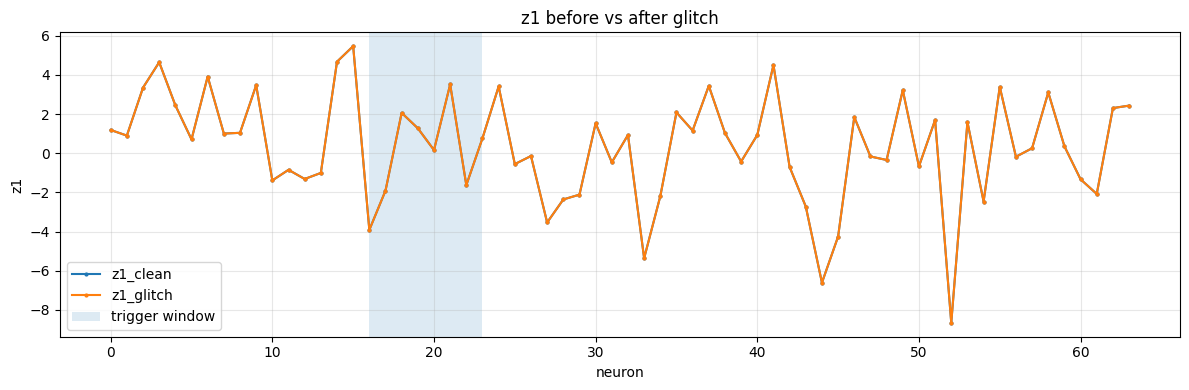

In [21]:
# ---- Plot 1: z1 clean vs glitched
if z1_c is not None and z1_g is not None:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(neurons, z1_c, label='z1_clean', marker='o', ms=2)
    ax.plot(neurons, z1_g, label='z1_glitch', marker='o', ms=2)
    ax.axvspan(DIVE_TRIGGER_START, DIVE_TRIGGER_STOP - 1, alpha=0.15, label='trigger window')
    ax.set_title('z1 before vs after glitch')
    ax.set_xlabel('neuron')
    ax.set_ylabel('z1')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUN_DIR / 'plot_z1_clean_vs_glitch.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping z1 plot: snapshot unavailable.')

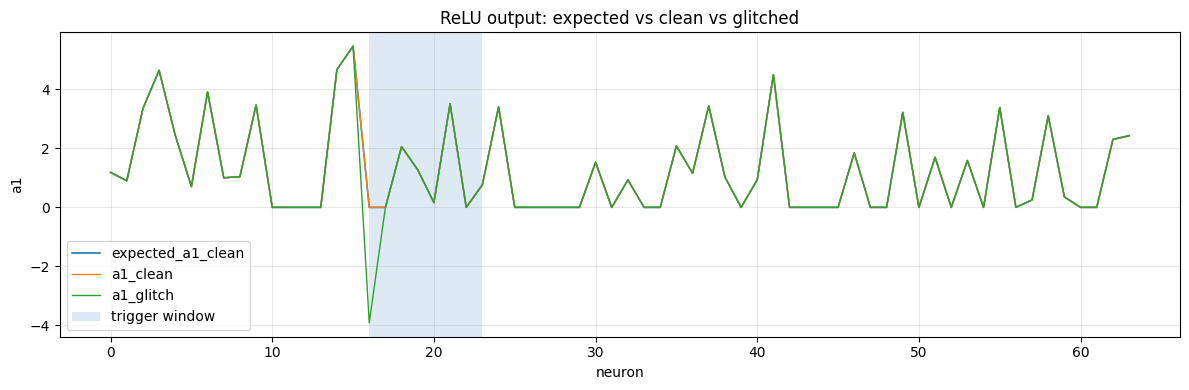

In [22]:
if a1_c is not None and a1_g is not None:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(neurons, expected_a1_clean, label='expected_a1_clean', lw=1.2)
    ax.plot(neurons, a1_c, label='a1_clean', lw=1.0)
    ax.plot(neurons, a1_g, label='a1_glitch', lw=1.0)
    ax.axvspan(DIVE_TRIGGER_START, DIVE_TRIGGER_STOP - 1, alpha=0.15, label='trigger window')
    ax.set_title('ReLU output: expected vs clean vs glitched')
    ax.set_xlabel('neuron')
    ax.set_ylabel('a1')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUN_DIR / 'plot_a1_expected_clean_glitch.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping a1 plot: snapshot unavailable.')

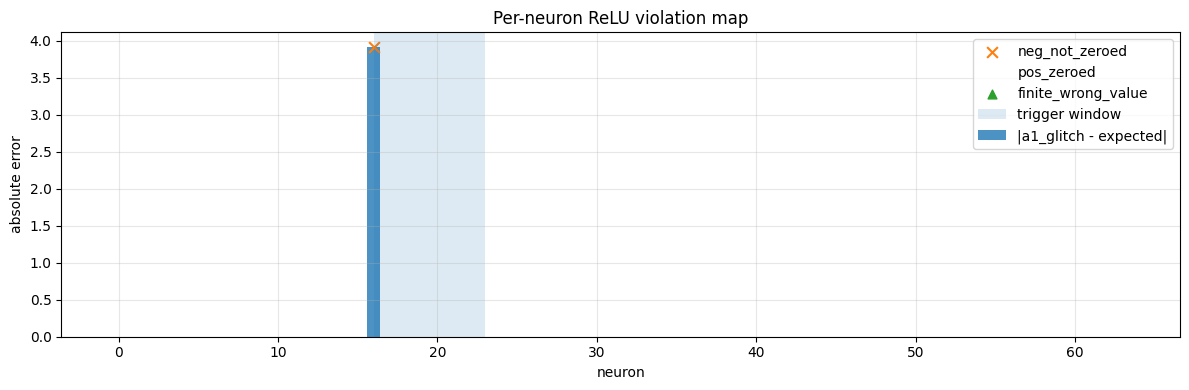

In [23]:
# ---- Plot 3: per-neuron errors and sign-violations
if 'abs_err_glitch' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(neurons, df['abs_err_glitch'], label='|a1_glitch - expected|', alpha=0.8)
    ax.scatter(df.loc[df['neg_not_zeroed'], 'neuron'],
               df.loc[df['neg_not_zeroed'], 'abs_err_glitch'],
               marker='x', s=60, label='neg_not_zeroed')
    ax.scatter(df.loc[df['pos_unexpectedly_zeroed'], 'neuron'],
               df.loc[df['pos_unexpectedly_zeroed'], 'abs_err_glitch'],
               marker='o', s=40, facecolors='none', label='pos_zeroed')
    ax.scatter(df.loc[df['finite_wrong_value'], 'neuron'],
               df.loc[df['finite_wrong_value'], 'abs_err_glitch'],
               marker='^', s=40, label='finite_wrong_value')
    ax.axvspan(DIVE_TRIGGER_START, DIVE_TRIGGER_STOP - 1, alpha=0.15, label='trigger window')
    ax.set_title('Per-neuron ReLU violation map')
    ax.set_xlabel('neuron')
    ax.set_ylabel('absolute error')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUN_DIR / 'plot_relu_violation_map.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping ReLU violation map: snapshot unavailable.')


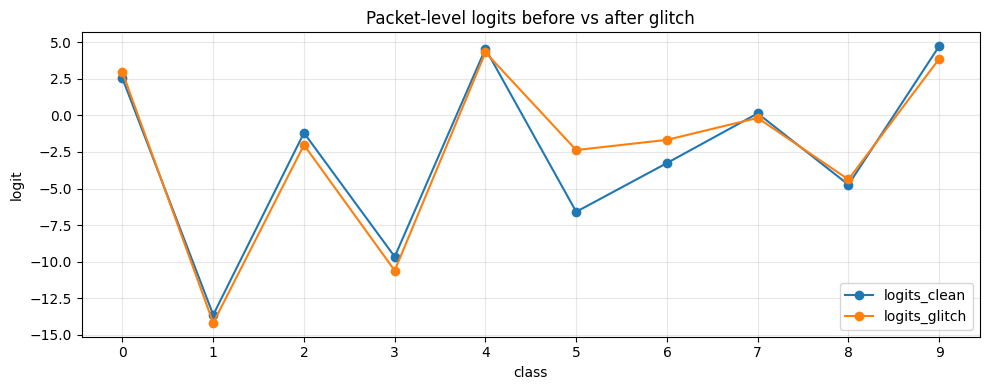

In [24]:
# ---- Plot 4: logits clean vs glitched
fig, ax = plt.subplots(figsize=(10, 4))
classes = np.arange(NN_OUT)
ax.plot(classes, logits_clean, marker='o', label='logits_clean')
ax.plot(classes, logits_glitch, marker='o', label='logits_glitch')
ax.set_xticks(classes)
ax.set_xlabel('class')
ax.set_ylabel('logit')
ax.set_title('Packet-level logits before vs after glitch')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(RUN_DIR / 'plot_logits_clean_vs_glitch.png', dpi=150, bbox_inches='tight')
plt.show()


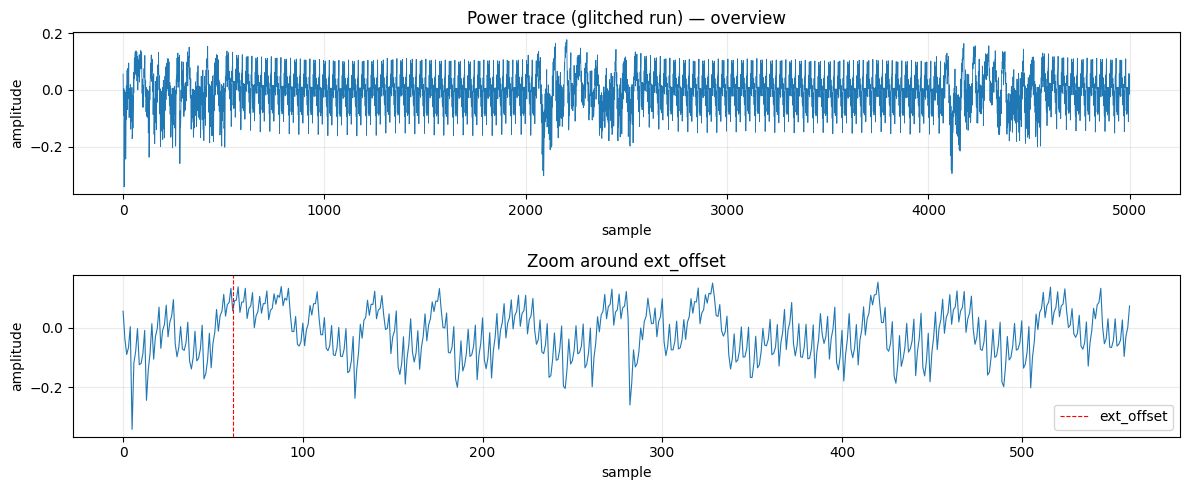

In [25]:
# ---- Plot 5: power trace overview + zoom around ext_offset (if captured)
if last_trace is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 5))
    axes[0].plot(last_trace, lw=0.6)
    axes[0].set_title('Power trace (glitched run) — overview')
    axes[0].set_xlabel('sample')
    axes[0].set_ylabel('amplitude')

    zoom_center = int(BEST_E)
    zoom_half = 500
    lo = max(0, zoom_center - zoom_half)
    hi = min(len(last_trace), zoom_center + zoom_half)
    axes[1].plot(np.arange(lo, hi), last_trace[lo:hi], lw=0.8)
    axes[1].axvline(zoom_center, color='r', ls='--', lw=0.8, label='ext_offset')
    axes[1].set_title('Zoom around ext_offset')
    axes[1].set_xlabel('sample')
    axes[1].set_ylabel('amplitude')
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(RUN_DIR / 'plot_trace_overview_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()

    np.save(RUN_DIR / 'trace_glitch.npy', np.asarray(last_trace, dtype=np.float32))
else:
    print('No trace captured (DIVE_CAPTURE_TRACE False or glitch failed).')

## 17. Verdict

This notebook now separates three very different cases:

1. **transport / trigger failure**  
   no-trigger, timeout, broken packet, UART desync;

2. **valid glitched inference without class flip**  
   logits changed, prediction may stay the same, but this is still useful for ReLU analysis;

3. **strong ReLU-local effect**  
   `z1` stays almost unchanged while `a1` violates `max(z1, 0)` and logits drift.

For the bachelor thesis / supervisor discussion, case 2 is already valuable if the
after-packet is valid and the deep-dive shows local ReLU violations inside the trigger window.


In [26]:
print('Notebook finished. See:')
print('  - coarse/fine CSV files in', RESULTS_ROOT.resolve())
print('  - deep-dive artifacts in', RUN_DIR.resolve())
print('  - relu_deep_dive_summary.csv for the one-row experiment summary')


Notebook finished. See:
  - coarse/fine CSV files in C:\Users\Admin\chipwhisperer\results_relu_only
  - deep-dive artifacts in C:\Users\Admin\chipwhisperer\results_relu_only\deep_dive\relu_deep_dive_20260425_154416
  - relu_deep_dive_summary.csv for the one-row experiment summary


## 19. Extra validation: no-glitch control + targeted ReLU attack repeats

This section is meant for the final report/defense. It does **not** repeat the large coarse sweep.
It uses the already discovered hot configuration and runs two small experiments:

1. **No-glitch control** on the same image: verifies that repeated inference does not produce ReLU violations without a clock glitch.
2. **Targeted glitch repeats** on the best tuple: estimates how often the attack produces valid packets, snapshots, ReLU violations, and prediction flips.

The important evidence is:

- `z1` should remain stable;
- `a1` should violate `a1=max(z1,0)` only under glitch;
- violations should be inside the trigger window;
- logits/prediction should change as a consequence of the corrupted `a1`.

In [27]:
CONTROL_REPEATS = 50
TARGETED_GLITCH_REPEATS = 50

# Use the hot tuple found earlier. You can override these manually if needed.
VALIDATION_TRIGGER_START = int(DIVE_TRIGGER_START if 'DIVE_TRIGGER_START' in globals() else BEST_TRIGGER_START)
VALIDATION_TRIGGER_STOP  = int(DIVE_TRIGGER_STOP  if 'DIVE_TRIGGER_STOP'  in globals() else BEST_TRIGGER_STOP)
VALIDATION_WIDTH         = float(BEST_W)
VALIDATION_OFFSET        = float(BEST_O)
VALIDATION_EXT_OFFSET    = int(BEST_E)

# Thresholds for clean/glitch comparison.
RELU_EPS = 1e-5
Z1_STABLE_THRESHOLD = 5e-2
A1_CHANGED_THRESHOLD = 1e-3

print('extra validation config:')
print(f'  control repeats          : {CONTROL_REPEATS}')
print(f'  targeted glitch repeats  : {TARGETED_GLITCH_REPEATS}')
print(f'  image                    : {dive_name}, label={dive_label}')
print(f'  window                   : [{VALIDATION_TRIGGER_START}, {VALIDATION_TRIGGER_STOP})')
print(f'  width/offset/ext         : {VALIDATION_WIDTH}, {VALIDATION_OFFSET}, {VALIDATION_EXT_OFFSET}')

extra validation config:
  control repeats          : 50
  targeted glitch repeats  : 50
  image                    : mnist_idx_4408_label_9, label=9
  window                   : [16, 24)
  width/offset/ext         : 3.0, 10.0, 61


In [28]:
def logits_are_plausible(logits, limit=LOGIT_ABS_SANITY_LIMIT):
    """Reject corrupted numeric packets with absurd float values."""
    if logits is None:
        return False
    arr = np.asarray(logits, dtype=np.float32)
    return bool(np.all(np.isfinite(arr)) and np.max(np.abs(arr)) <= float(limit))


def relu_metrics_from_snapshots(clean_snap, test_snap, trigger_start, trigger_stop, eps=RELU_EPS):
    """Compute per-neuron ReLU evidence from clean and tested snapshots."""
    z1_clean = np.asarray(clean_snap['z1'], dtype=np.float32)
    a1_clean = np.asarray(clean_snap['a1'], dtype=np.float32)
    z1_test  = np.asarray(test_snap['z1'], dtype=np.float32)
    a1_test  = np.asarray(test_snap['a1'], dtype=np.float32)

    neurons = np.arange(NN_HID)
    in_window = (neurons >= int(trigger_start)) & (neurons < int(trigger_stop))

    expected_clean = np.maximum(z1_clean, 0.0)
    expected_test  = np.maximum(z1_test, 0.0)

    clean_relu_error = a1_clean - expected_clean
    test_relu_error  = a1_test  - expected_test

    clean_abs_err = np.abs(clean_relu_error)
    test_abs_err  = np.abs(test_relu_error)

    z1_delta = z1_test - z1_clean
    a1_delta = a1_test - a1_clean

    violation = test_abs_err > eps
    clean_violation = clean_abs_err > eps
    neg_not_zeroed = (z1_test < -eps) & (np.abs(a1_test) > eps)
    pos_unexpectedly_zeroed = (z1_test > eps) & (np.abs(a1_test) < eps)
    finite_wrong_value = violation & (~neg_not_zeroed) & (~pos_unexpectedly_zeroed)

    df = pd.DataFrame({
        'neuron': neurons,
        'in_trigger_window': in_window,
        'z1_clean': z1_clean,
        'z1_test': z1_test,
        'z1_delta': z1_delta,
        'abs_z1_delta': np.abs(z1_delta),
        'a1_clean': a1_clean,
        'a1_test': a1_test,
        'a1_delta': a1_delta,
        'abs_a1_delta': np.abs(a1_delta),
        'expected_a1_clean': expected_clean,
        'expected_a1_test': expected_test,
        'clean_relu_error': clean_relu_error,
        'test_relu_error': test_relu_error,
        'abs_clean_relu_error': clean_abs_err,
        'abs_test_relu_error': test_abs_err,
        'clean_violation': clean_violation,
        'violation': violation,
        'neg_not_zeroed': neg_not_zeroed,
        'pos_unexpectedly_zeroed': pos_unexpectedly_zeroed,
        'finite_wrong_value': finite_wrong_value,
    })

    summary = {
        'snapshot_ok': True,
        'n_violations': int(violation.sum()),
        'n_violations_in_window': int((violation & in_window).sum()),
        'n_violations_outside_window': int((violation & ~in_window).sum()),
        'n_clean_violations': int(clean_violation.sum()),
        'n_neg_not_zeroed': int(neg_not_zeroed.sum()),
        'n_pos_unexpectedly_zeroed': int(pos_unexpectedly_zeroed.sum()),
        'n_finite_wrong_value': int(finite_wrong_value.sum()),
        'max_abs_z1_delta': float(np.max(np.abs(z1_delta))),
        'max_abs_a1_delta': float(np.max(np.abs(a1_delta))),
        'max_abs_relu_error': float(np.max(test_abs_err)),
        'relu_only_hint': bool(np.max(np.abs(z1_delta)) <= Z1_STABLE_THRESHOLD and np.max(np.abs(a1_delta)) > A1_CHANGED_THRESHOLD),
    }

    if violation.any():
        first_bad = int(df.loc[df['violation'], 'neuron'].iloc[0])
        worst_bad = int(df.sort_values('abs_test_relu_error', ascending=False)['neuron'].iloc[0])
        summary.update({
            'first_bad_neuron': first_bad,
            'worst_bad_neuron': worst_bad,
            'worst_bad_error': float(df.loc[df['neuron'] == worst_bad, 'abs_test_relu_error'].iloc[0]),
        })
    else:
        summary.update({'first_bad_neuron': None, 'worst_bad_neuron': None, 'worst_bad_error': 0.0})

    return df, summary


def packet_diff_summary(clean_pkt, test_pkt):
    if clean_pkt is None or test_pkt is None or clean_pkt.get('logits') is None or test_pkt.get('logits') is None:
        return {}
    clean_logits = np.asarray(clean_pkt['logits'], dtype=np.float32)
    test_logits = np.asarray(test_pkt['logits'], dtype=np.float32)
    return {
        'clean_pred': int(clean_pkt.get('pred')),
        'test_pred': int(test_pkt.get('pred')),
        'prediction_changed': bool(int(clean_pkt.get('pred')) != int(test_pkt.get('pred'))),
        'logit_l1_diff': float(np.sum(np.abs(test_logits - clean_logits))),
        'logit_max_abs_diff': float(np.max(np.abs(test_logits - clean_logits))),
        'margin_clean': float(top2_margin(clean_logits)),
        'margin_test': float(top2_margin(test_logits)),
        'margin_drop': float(top2_margin(clean_logits) - top2_margin(test_logits)),
        'logits_plausible': logits_are_plausible(test_logits),
    }

print('extra validation helpers ready')

extra validation helpers ready


In [29]:
def run_no_glitch_control_repeats(n=CONTROL_REPEATS):
    """Repeated inference with no clock glitch. Expected: no ReLU violations, stable prediction."""
    rows = []
    neuron_tables = []

    for i in range(1, int(n) + 1):
        row = {
            'mode': 'no_glitch_control',
            'attempt': i,
            'packet_valid': False,
            'snapshot_ok': False,
            'error': None,
        }
        try:
            recover_target(
                dive_img,
                act_type=ACT_RELU,
                fault_model=FAULT_NONE,
                trigger_mode=TRIGMODE_WINDOW,
                trigger_start=VALIDATION_TRIGGER_START,
                trigger_stop=VALIDATION_TRIGGER_STOP,
            )
            cmd_clear()
            cmd_upload_image(dive_img)
            cmd_set_activation(ACT_RELU)
            cmd_set_fault(FAULT_NONE)
            cmd_set_trigger_window(TRIGMODE_WINDOW, VALIDATION_TRIGGER_START, VALIDATION_TRIGGER_STOP)

            clean_pkt = cmd_baseline_packet()
            clean_snap = snapshot_clean()

            # No glitch: keep normal clock, just run inference packet.
            scope.io.hs2 = 'clkgen'
            time.sleep(0.02)
            test_pkt = cmd_infer_packet()
            row['packet_valid'] = bool(test_pkt.get('valid', False) and test_pkt.get('finite', False) and test_pkt.get('consistent', False))
            row.update(packet_diff_summary(clean_pkt, test_pkt))

            test_snap = snapshot_glitched(packet_logits=test_pkt['logits'])
            df, s = relu_metrics_from_snapshots(clean_snap, test_snap, VALIDATION_TRIGGER_START, VALIDATION_TRIGGER_STOP)
            row.update(s)
            row['snapshot_ok'] = True
            df['mode'] = 'no_glitch_control'
            df['attempt'] = i
            neuron_tables.append(df)

        except Exception as e:
            row['error'] = str(e)

        rows.append(row)
        if i % 10 == 0 or i == 1 or i == n:
            print(f'control {i}/{n}: packet={row.get("packet_valid")}, snapshot={row.get("snapshot_ok")}, pred={row.get("test_pred")}, violations={row.get("n_violations")}')

    control_df = pd.DataFrame(rows)
    control_neurons_df = pd.concat(neuron_tables, ignore_index=True) if neuron_tables else pd.DataFrame()
    return control_df, control_neurons_df


control_df, control_neurons_df = run_no_glitch_control_repeats(CONTROL_REPEATS)
control_df.to_csv(RUN_DIR / 'no_glitch_control_repeats.csv', index=False)
control_neurons_df.to_csv(RUN_DIR / 'no_glitch_control_per_neuron.csv', index=False)

print('\nNo-glitch control summary:')
display(control_df)

control 1/50: packet=True, snapshot=True, pred=9, violations=0
control 10/50: packet=True, snapshot=True, pred=9, violations=0
control 20/50: packet=True, snapshot=True, pred=9, violations=0
control 30/50: packet=True, snapshot=True, pred=9, violations=0
control 40/50: packet=True, snapshot=True, pred=9, violations=0
control 50/50: packet=True, snapshot=True, pred=9, violations=0

No-glitch control summary:


,mode,attempt,packet_valid,snapshot_ok,error,clean_pred,test_pred,prediction_changed,logit_l1_diff,logit_max_abs_diff,...,n_neg_not_zeroed,n_pos_unexpectedly_zeroed,n_finite_wrong_value,max_abs_z1_delta,max_abs_a1_delta,max_abs_relu_error,relu_only_hint,first_bad_neuron,worst_bad_neuron,worst_bad_error
0,no_glitch_control,1,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
1,no_glitch_control,2,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
2,no_glitch_control,3,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
3,no_glitch_control,4,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
4,no_glitch_control,5,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
5,no_glitch_control,6,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
6,no_glitch_control,7,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
7,no_glitch_control,8,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
8,no_glitch_control,9,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0
9,no_glitch_control,10,True,True,None,9,9,False,0.0,0.0,...,0,0,0,0.0,0.0,0.0,False,None,None,0.0


In [30]:
def run_targeted_glitch_repeats(n=TARGETED_GLITCH_REPEATS):
    """Repeat only the best ReLU glitch tuple. Goal: snapshot statistics + ReLU violation statistics."""
    rows = []
    neuron_tables = []
    best_snapshot = None
    best_snapshot_score = float('-inf')

    scope.glitch.width = VALIDATION_WIDTH
    scope.glitch.offset = VALIDATION_OFFSET
    scope.glitch.ext_offset = VALIDATION_EXT_OFFSET

    for i in range(1, int(n) + 1):
        row = {
            'mode': 'targeted_glitch',
            'attempt': i,
            'width': VALIDATION_WIDTH,
            'offset': VALIDATION_OFFSET,
            'ext_offset': VALIDATION_EXT_OFFSET,
            'trigger_start': VALIDATION_TRIGGER_START,
            'trigger_stop': VALIDATION_TRIGGER_STOP,
            'timed_out': False,
            'packet_valid': False,
            'snapshot_ok': False,
            'error': None,
        }

        try:
            recover_target(
                dive_img,
                act_type=ACT_RELU,
                fault_model=FAULT_NONE,
                trigger_mode=TRIGMODE_WINDOW,
                trigger_start=VALIDATION_TRIGGER_START,
                trigger_stop=VALIDATION_TRIGGER_STOP,
            )
            cmd_clear()
            cmd_upload_image(dive_img)
            cmd_set_activation(ACT_RELU)
            cmd_set_fault(FAULT_NONE)
            cmd_set_trigger_window(TRIGMODE_WINDOW, VALIDATION_TRIGGER_START, VALIDATION_TRIGGER_STOP)

            clean_pkt = cmd_baseline_packet()
            clean_snap = snapshot_clean()

            scope.io.hs2 = 'glitch'
            flush_target()
            scope.arm()
            ss_write('g', b'')
            timed_out = scope.capture()
            scope.io.hs2 = 'clkgen'
            time.sleep(POST_GLITCH_SETTLE_S)

            if timed_out:
                row['timed_out'] = True
                row['error'] = 'scope_capture_timeout'
                rows.append(row)
                continue

            raw = ss_read_exact(PACKET_BYTES, timeout=UART_TIMEOUT_MS)
            test_pkt = parse_result_packet(raw)
            row['packet_valid'] = bool(test_pkt.get('valid', False) and test_pkt.get('finite', False) and test_pkt.get('consistent', False))
            row['packet_reason'] = test_pkt.get('reason')
            row.update(packet_diff_summary(clean_pkt, test_pkt))

            if not row['packet_valid']:
                rows.append(row)
                continue

            if not logits_are_plausible(test_pkt['logits']):
                row['error'] = 'corrupted_numeric_packet_implausible_logits'
                rows.append(row)
                continue

            test_snap = snapshot_glitched(packet_logits=test_pkt['logits'])
            df, s = relu_metrics_from_snapshots(clean_snap, test_snap, VALIDATION_TRIGGER_START, VALIDATION_TRIGGER_STOP)
            row.update(s)
            row['snapshot_ok'] = True
            df['mode'] = 'targeted_glitch'
            df['attempt'] = i
            neuron_tables.append(df)

            # Prefer: prediction flip + in-window ReLU violation + stable z1.
            score = 0.0
            score += 1000.0 if row.get('prediction_changed') else 0.0
            score += 100.0 * int(row.get('n_violations_in_window', 0))
            score += 10.0 * float(row.get('logit_l1_diff', 0.0))
            score += float(row.get('max_abs_relu_error', 0.0))
            score -= 50.0 * float(row.get('max_abs_z1_delta', 0.0))

            if score > best_snapshot_score:
                best_snapshot_score = score
                best_snapshot = {
                    'row': dict(row),
                    'clean_pkt': clean_pkt,
                    'test_pkt': test_pkt,
                    'clean_snap': clean_snap,
                    'test_snap': test_snap,
                    'per_neuron': df.copy(),
                }

        except Exception as e:
            row['error'] = str(e)

        rows.append(row)
        if i % 10 == 0 or i == 1 or i == n:
            print(f'glitch {i}/{n}: packet={row.get("packet_valid")}, snapshot={row.get("snapshot_ok")}, pred={row.get("test_pred")}, violations={row.get("n_violations")}, in_window={row.get("n_violations_in_window")}, err={row.get("error")}')

    glitch_df = pd.DataFrame(rows)
    glitch_neurons_df = pd.concat(neuron_tables, ignore_index=True) if neuron_tables else pd.DataFrame()
    return glitch_df, glitch_neurons_df, best_snapshot


glitch_validation_df, glitch_validation_neurons_df, best_validation_snapshot = run_targeted_glitch_repeats(TARGETED_GLITCH_REPEATS)
glitch_validation_df.to_csv(RUN_DIR / 'targeted_glitch_repeats.csv', index=False)
glitch_validation_neurons_df.to_csv(RUN_DIR / 'targeted_glitch_per_neuron.csv', index=False)

if best_validation_snapshot is not None:
    best_validation_snapshot['per_neuron'].to_csv(RUN_DIR / 'best_targeted_glitch_per_neuron.csv', index=False)

print('\nTargeted glitch repeat summary:')
display(glitch_validation_df)

glitch 1/50: packet=True, snapshot=True, pred=4, violations=1, in_window=1, err=None
glitch 10/50: packet=True, snapshot=True, pred=4, violations=1, in_window=1, err=None
glitch 20/50: packet=True, snapshot=True, pred=4, violations=1, in_window=1, err=None
glitch 30/50: packet=True, snapshot=True, pred=4, violations=1, in_window=1, err=None
glitch 40/50: packet=True, snapshot=True, pred=4, violations=1, in_window=1, err=None
glitch 50/50: packet=True, snapshot=True, pred=4, violations=1, in_window=1, err=None

Targeted glitch repeat summary:


,mode,attempt,width,offset,ext_offset,trigger_start,trigger_stop,timed_out,packet_valid,snapshot_ok,...,n_neg_not_zeroed,n_pos_unexpectedly_zeroed,n_finite_wrong_value,max_abs_z1_delta,max_abs_a1_delta,max_abs_relu_error,relu_only_hint,first_bad_neuron,worst_bad_neuron,worst_bad_error
0,targeted_glitch,1,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
1,targeted_glitch,2,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
2,targeted_glitch,3,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
3,targeted_glitch,4,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
4,targeted_glitch,5,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
5,targeted_glitch,6,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
6,targeted_glitch,7,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
7,targeted_glitch,8,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
8,targeted_glitch,9,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523
9,targeted_glitch,10,3.0,10.0,61,16,24,False,True,True,...,1,0,0,0.0,3.916523,3.916523,True,16,16,3.916523


In [31]:
# ---------------- Compact report table: control vs glitch ----------------
def rate(df, col):
    if df is None or len(df) == 0 or col not in df.columns:
        return float('nan')
    return float(pd.to_numeric(df[col], errors='coerce').fillna(False).astype(bool).mean())

def mean_num(df, col):
    if df is None or len(df) == 0 or col not in df.columns:
        return float('nan')
    return float(pd.to_numeric(df[col], errors='coerce').mean())

def max_num(df, col):
    if df is None or len(df) == 0 or col not in df.columns:
        return float('nan')
    return float(pd.to_numeric(df[col], errors='coerce').max())

comparison_rows = []
for name, df in [('No-glitch control', control_df), ('Targeted ReLU glitch', glitch_validation_df)]:
    comparison_rows.append({
        'experiment': name,
        'attempts': int(len(df)),
        'packet_valid_rate': rate(df, 'packet_valid'),
        'snapshot_ok_rate': rate(df, 'snapshot_ok'),
        'prediction_flip_rate': rate(df, 'prediction_changed'),
        'relu_violation_rate': rate(df, 'n_violations'),
        'in_window_violation_rate': rate(df, 'n_violations_in_window'),
        'mean_logit_l1_diff': mean_num(df, 'logit_l1_diff'),
        'max_logit_l1_diff': max_num(df, 'logit_l1_diff'),
        'mean_max_abs_relu_error': mean_num(df, 'max_abs_relu_error'),
        'max_abs_relu_error': max_num(df, 'max_abs_relu_error'),
        'mean_max_abs_z1_delta': mean_num(df, 'max_abs_z1_delta'),
        'max_abs_z1_delta': max_num(df, 'max_abs_z1_delta'),
    })

validation_comparison_df = pd.DataFrame(comparison_rows)
validation_comparison_df.to_csv(RUN_DIR / 'validation_control_vs_glitch_summary.csv', index=False)

display(validation_comparison_df)
print('saved:', RUN_DIR / 'validation_control_vs_glitch_summary.csv')

,experiment,attempts,packet_valid_rate,snapshot_ok_rate,prediction_flip_rate,relu_violation_rate,in_window_violation_rate,mean_logit_l1_diff,max_logit_l1_diff,mean_max_abs_relu_error,max_abs_relu_error,mean_max_abs_z1_delta,max_abs_z1_delta
0,No-glitch control,50,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,Targeted ReLU glitch,50,1.0,1.0,1.0,1.0,1.0,10.313059,10.313059,3.916523,3.916523,0.0,0.0


saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\validation_control_vs_glitch_summary.csv


In [32]:
# ---------------- Pretty table: best per-neuron ReLU violation evidence ----------------
if best_validation_snapshot is not None:
    best_df = best_validation_snapshot['per_neuron'].copy()
else:
    # Fallback to the already selected one-shot deep-dive result from the previous section.
    best_df = df.copy() if 'df' in globals() and isinstance(df, pd.DataFrame) else pd.DataFrame()

if len(best_df):
    cols = [
        'neuron', 'in_trigger_window',
        'z1_clean', 'z1_test', 'z1_delta',
        'expected_a1_test', 'a1_clean', 'a1_test', 'a1_delta',
        'test_relu_error', 'abs_test_relu_error',
        'violation', 'neg_not_zeroed', 'pos_unexpectedly_zeroed', 'finite_wrong_value',
    ]
    pretty_best = best_df[cols].copy()
    pretty_best = pretty_best.sort_values(['violation', 'abs_test_relu_error'], ascending=[False, False])
    pretty_best.to_csv(RUN_DIR / 'best_relu_violation_table_pretty.csv', index=False)

    print('Top neurons by ReLU error / violation:')
    display(pretty_best.head(16))
    print('saved:', RUN_DIR / 'best_relu_violation_table_pretty.csv')
else:
    print('No per-neuron table available yet. Need at least one snapshot_ok=True attempt.')

Top neurons by ReLU error / violation:


,neuron,in_trigger_window,z1_clean,z1_test,z1_delta,expected_a1_test,a1_clean,a1_test,a1_delta,test_relu_error,abs_test_relu_error,violation,neg_not_zeroed,pos_unexpectedly_zeroed,finite_wrong_value
16,16,True,-3.916523,-3.916523,0.0,0.000000,0.000000,-3.916523,-3.916523,-3.916523,3.916523,True,True,False,False
0,0,False,1.185982,1.185982,0.0,1.185982,1.185982,1.185982,0.000000,0.000000,0.000000,False,False,False,False
1,1,False,0.898466,0.898466,0.0,0.898466,0.898466,0.898466,0.000000,0.000000,0.000000,False,False,False,False
2,2,False,3.347604,3.347604,0.0,3.347604,3.347604,3.347604,0.000000,0.000000,0.000000,False,False,False,False
3,3,False,4.645538,4.645538,0.0,4.645538,4.645538,4.645538,0.000000,0.000000,0.000000,False,False,False,False
4,4,False,2.445874,2.445874,0.0,2.445874,2.445874,2.445874,0.000000,0.000000,0.000000,False,False,False,False
5,5,False,0.705370,0.705370,0.0,0.705370,0.705370,0.705370,0.000000,0.000000,0.000000,False,False,False,False
6,6,False,3.913244,3.913244,0.0,3.913244,3.913244,3.913244,0.000000,0.000000,0.000000,False,False,False,False
7,7,False,1.003572,1.003572,0.0,1.003572,1.003572,1.003572,0.000000,0.000000,0.000000,False,False,False,False
8,8,False,1.040600,1.040600,0.0,1.040600,1.040600,1.040600,0.000000,0.000000,0.000000,False,False,False,False


saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\best_relu_violation_table_pretty.csv


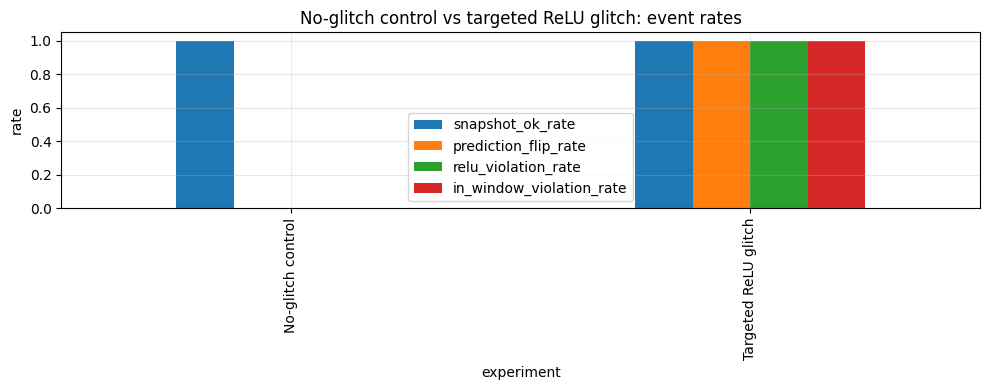

saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\validation_rates_control_vs_glitch.png


In [33]:
plot_df = validation_comparison_df.set_index('experiment')
metrics_to_plot = [
    'snapshot_ok_rate',
    'prediction_flip_rate',
    'relu_violation_rate',
    'in_window_violation_rate',
]

fig, ax = plt.subplots(figsize=(10, 4))
plot_df[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('rate')
ax.set_title('No-glitch control vs targeted ReLU glitch: event rates')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(RUN_DIR / 'validation_rates_control_vs_glitch.png', dpi=180)
plt.show()

print('saved:', RUN_DIR / 'validation_rates_control_vs_glitch.png')

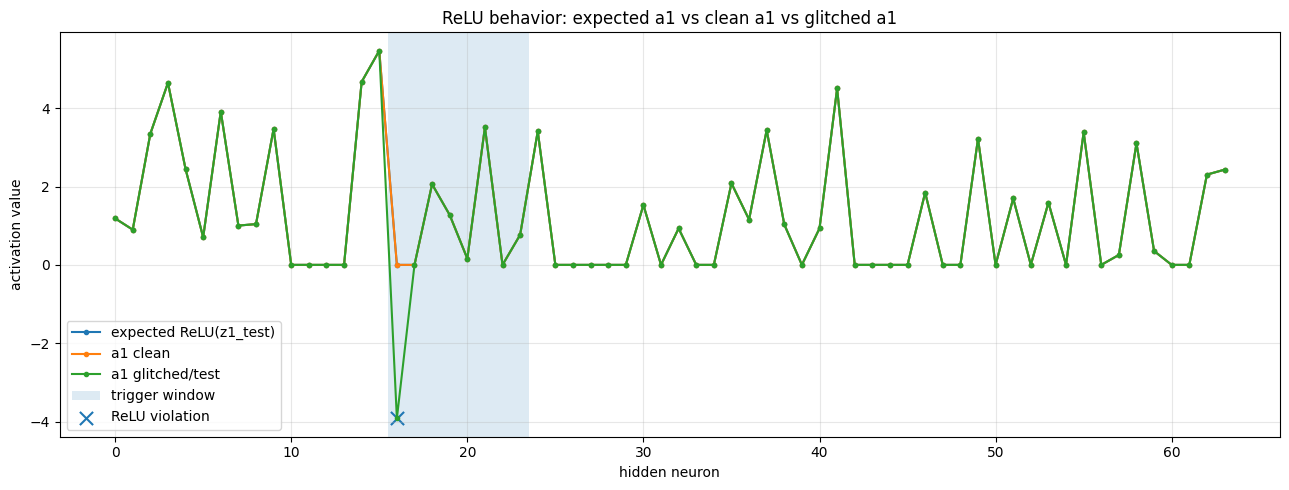

saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\best_a1_expected_clean_glitch_comparison.png


In [34]:
# ---------------- Plot B: clean vs glitched a1, expected ReLU, and violation marker ----------------
if len(best_df):
    neurons = best_df['neuron'].to_numpy()
    in_window = best_df['in_trigger_window'].astype(bool).to_numpy()
    violations = best_df['violation'].astype(bool).to_numpy()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(neurons, best_df['expected_a1_test'], marker='o', ms=3, label='expected ReLU(z1_test)')
    ax.plot(neurons, best_df['a1_clean'], marker='o', ms=3, label='a1 clean')
    ax.plot(neurons, best_df['a1_test'], marker='o', ms=3, label='a1 glitched/test')

    # Mark trigger window and violations.
    ax.axvspan(VALIDATION_TRIGGER_START - 0.5, VALIDATION_TRIGGER_STOP - 0.5, alpha=0.15, label='trigger window')
    if violations.any():
        ax.scatter(best_df.loc[violations, 'neuron'], best_df.loc[violations, 'a1_test'], s=90, marker='x', label='ReLU violation')

    ax.set_xlabel('hidden neuron')
    ax.set_ylabel('activation value')
    ax.set_title('ReLU behavior: expected a1 vs clean a1 vs glitched a1')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(RUN_DIR / 'best_a1_expected_clean_glitch_comparison.png', dpi=180)
    plt.show()

    print('saved:', RUN_DIR / 'best_a1_expected_clean_glitch_comparison.png')
else:
    print('Skipping plot: no best per-neuron snapshot table.')

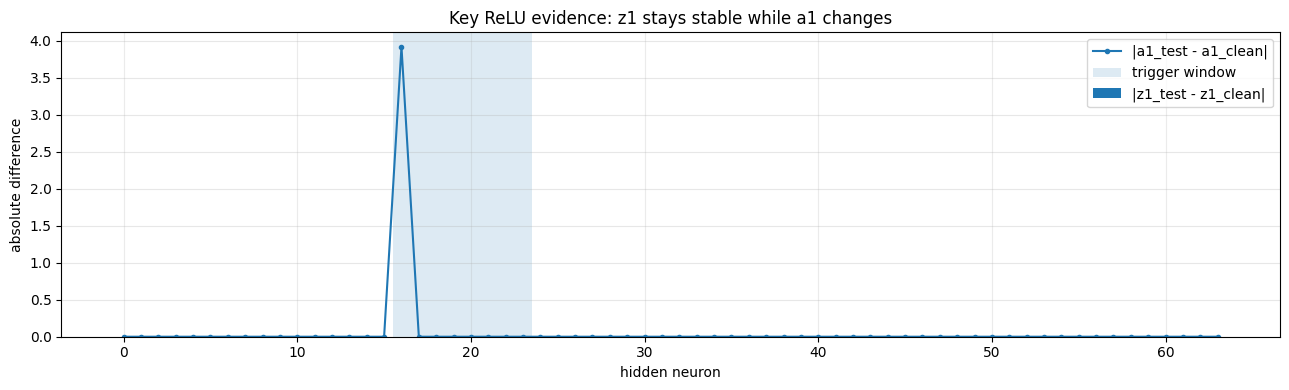

saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\best_z1_stability_vs_a1_corruption.png


In [35]:
# ---------------- Plot C: z1 stability vs a1 corruption ----------------
if len(best_df):
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(best_df['neuron'], best_df['abs_z1_delta'], label='|z1_test - z1_clean|')
    ax.plot(best_df['neuron'], best_df['abs_a1_delta'], marker='o', ms=3, label='|a1_test - a1_clean|')
    ax.axvspan(VALIDATION_TRIGGER_START - 0.5, VALIDATION_TRIGGER_STOP - 0.5, alpha=0.15, label='trigger window')
    ax.set_xlabel('hidden neuron')
    ax.set_ylabel('absolute difference')
    ax.set_title('Key ReLU evidence: z1 stays stable while a1 changes')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(RUN_DIR / 'best_z1_stability_vs_a1_corruption.png', dpi=180)
    plt.show()

    print('saved:', RUN_DIR / 'best_z1_stability_vs_a1_corruption.png')
else:
    print('Skipping plot: no best per-neuron snapshot table.')

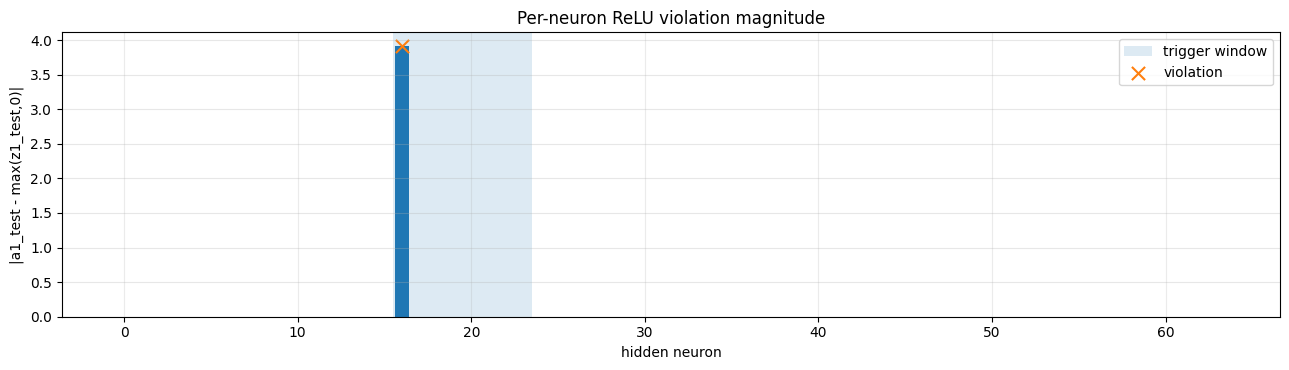

saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\best_relu_violation_magnitude_map.png


In [36]:
# ---------------- Plot D: ReLU error heatmap / stem-like map ----------------
if len(best_df):
    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.bar(best_df['neuron'], best_df['abs_test_relu_error'])
    ax.axvspan(VALIDATION_TRIGGER_START - 0.5, VALIDATION_TRIGGER_STOP - 0.5, alpha=0.15, label='trigger window')
    bad = best_df['violation'].astype(bool)
    if bad.any():
        ax.scatter(best_df.loc[bad, 'neuron'], best_df.loc[bad, 'abs_test_relu_error'], s=90, marker='x', label='violation')
    ax.set_xlabel('hidden neuron')
    ax.set_ylabel('|a1_test - max(z1_test,0)|')
    ax.set_title('Per-neuron ReLU violation magnitude')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(RUN_DIR / 'best_relu_violation_magnitude_map.png', dpi=180)
    plt.show()

    print('saved:', RUN_DIR / 'best_relu_violation_magnitude_map.png')
else:
    print('Skipping plot: no best per-neuron snapshot table.')

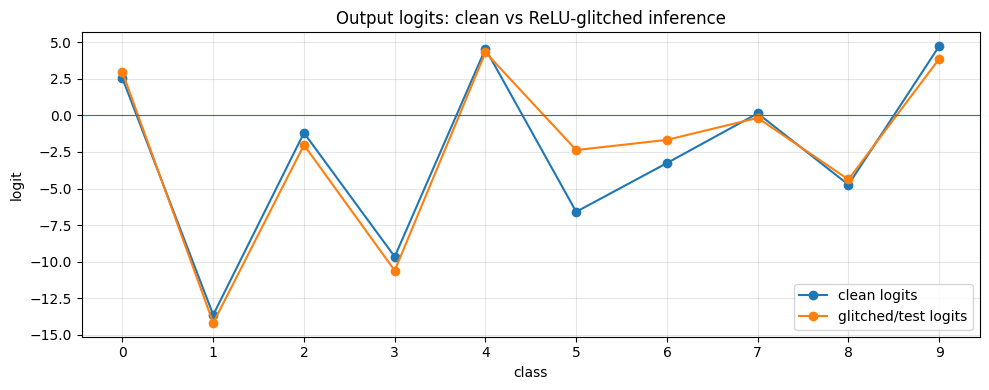

,class,clean_logit,glitched_logit,delta,abs_delta
5,5,-6.587747,-2.368421,4.219326,4.219326
6,6,-3.258457,-1.672673,1.585784,1.585784
3,3,-9.656887,-10.603271,-0.946384,0.946384
9,9,4.729550,3.864743,-0.864807,0.864807
2,2,-1.194577,-2.020119,-0.825542,0.825542
1,1,-13.629911,-14.178698,-0.548786,0.548786
0,0,2.522987,2.935059,0.412072,0.412072
8,8,-4.736228,-4.379904,0.356324,0.356324
7,7,0.136177,-0.172489,-0.308666,0.308666
4,4,4.551976,4.306609,-0.245367,0.245367


saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\best_logits_clean_vs_glitch_validation.png
saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\best_logits_delta_table.csv


In [37]:
# ---------------- Plot E: logits before/after for best validation snapshot ----------------
if best_validation_snapshot is not None:
    clean_logits = np.asarray(best_validation_snapshot['clean_pkt']['logits'], dtype=np.float32)
    test_logits = np.asarray(best_validation_snapshot['test_pkt']['logits'], dtype=np.float32)
else:
    clean_logits = np.asarray(logits_clean, dtype=np.float32) if 'logits_clean' in globals() else None
    test_logits = np.asarray(logits_glitch, dtype=np.float32) if 'logits_glitch' in globals() else None

if clean_logits is not None and test_logits is not None:
    classes = np.arange(NN_OUT)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(classes, clean_logits, marker='o', label='clean logits')
    ax.plot(classes, test_logits, marker='o', label='glitched/test logits')
    ax.axhline(0, lw=0.8)
    ax.set_xticks(classes)
    ax.set_xlabel('class')
    ax.set_ylabel('logit')
    ax.set_title('Output logits: clean vs ReLU-glitched inference')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(RUN_DIR / 'best_logits_clean_vs_glitch_validation.png', dpi=180)
    plt.show()

    logit_table = pd.DataFrame({
        'class': classes,
        'clean_logit': clean_logits,
        'glitched_logit': test_logits,
        'delta': test_logits - clean_logits,
        'abs_delta': np.abs(test_logits - clean_logits),
    }).sort_values('abs_delta', ascending=False)
    logit_table.to_csv(RUN_DIR / 'best_logits_delta_table.csv', index=False)
    display(logit_table)
    print('saved:', RUN_DIR / 'best_logits_clean_vs_glitch_validation.png')
    print('saved:', RUN_DIR / 'best_logits_delta_table.csv')
else:
    print('Skipping logits plot: no logits available.')

In [38]:
# ---------------- Final validation verdict auto-text ----------------
if len(validation_comparison_df):
    ctrl = validation_comparison_df.set_index('experiment').loc['No-glitch control']
    glit = validation_comparison_df.set_index('experiment').loc['Targeted ReLU glitch']

    print('=== VALIDATION VERDICT ===')
    print(f'No-glitch control: packet_valid_rate={ctrl.packet_valid_rate:.3f}, snapshot_ok_rate={ctrl.snapshot_ok_rate:.3f}, relu_violation_rate={ctrl.relu_violation_rate:.3f}')
    print(f'Targeted glitch   : packet_valid_rate={glit.packet_valid_rate:.3f}, snapshot_ok_rate={glit.snapshot_ok_rate:.3f}, relu_violation_rate={glit.relu_violation_rate:.3f}, prediction_flip_rate={glit.prediction_flip_rate:.3f}')
    print()

    if glit.snapshot_ok_rate > 0 and glit.relu_violation_rate > 0 and ctrl.relu_violation_rate == 0:
        print('Result: STRONG ReLU-specific evidence.')
        print('Reason: no-glitch control has no ReLU violations, while targeted glitch produces snapshot-backed ReLU violations.')
    elif glit.snapshot_ok_rate > 0 and glit.relu_violation_rate > 0:
        print('Result: ReLU-specific evidence exists, but inspect the no-glitch control because it also reported violations or failed snapshots.')
    elif glit.snapshot_ok_rate > 0:
        print('Result: snapshots are available, but this repeat set did not capture a ReLU violation. Use the earlier successful snapshot or increase repeats.')
    else:
        print('Result: packet-level evidence only in this repeat set. Snapshot readout failed; reduce width or increase POST_GLITCH_SETTLE_S.')

=== VALIDATION VERDICT ===
No-glitch control: packet_valid_rate=1.000, snapshot_ok_rate=1.000, relu_violation_rate=0.000
Targeted glitch   : packet_valid_rate=1.000, snapshot_ok_rate=1.000, relu_violation_rate=1.000, prediction_flip_rate=1.000

Result: STRONG ReLU-specific evidence.
Reason: no-glitch control has no ReLU violations, while targeted glitch produces snapshot-backed ReLU violations.


REPORT TABLE 1: Control vs targeted ReLU glitch


,experiment,attempts,packet_valid_rate,snapshot_ok_rate,prediction_flip_rate,relu_violation_rate,in_window_violation_rate,mean_logit_l1_diff,max_logit_l1_diff,mean_max_abs_relu_error,max_abs_relu_error,mean_max_abs_z1_delta,max_abs_z1_delta
0,No-glitch control,50,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,Targeted ReLU glitch,50,1.0,1.0,1.0,1.0,1.0,10.313059,10.313059,3.916523,3.916523,0.0,0.0


saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\01_control_vs_glitch_summary.csv


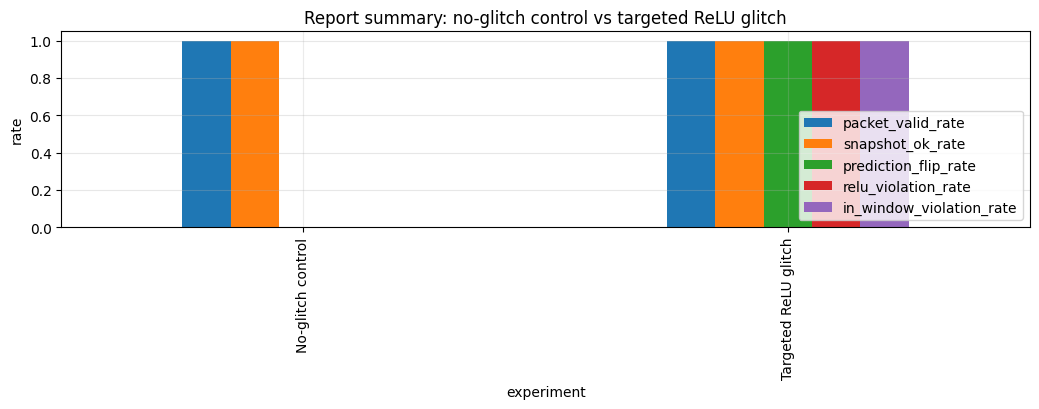

saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\01_control_vs_glitch_summary.png


In [39]:

# ---------------- Report-ready best case evidence pack ----------------
# This block does not run any new hardware experiment. It only extracts the best evidence
# from the validation results already produced above and saves a compact artifact set.

REPORT_DIR = RUN_DIR / 'report_ready_best_case'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ---- 1) Load or reuse validation summary ----
if 'validation_comparison_df' not in globals() or validation_comparison_df is None or len(validation_comparison_df) == 0:
    summary_path = RUN_DIR / 'validation_control_vs_glitch_summary.csv'
    if summary_path.exists():
        validation_comparison_df = pd.read_csv(summary_path)
    else:
        raise RuntimeError('validation_comparison_df is missing. Run the enhanced validation cells first.')

report_summary_cols = [
    'experiment',
    'attempts',
    'packet_valid_rate',
    'snapshot_ok_rate',
    'prediction_flip_rate',
    'relu_violation_rate',
    'in_window_violation_rate',
    'mean_logit_l1_diff',
    'max_logit_l1_diff',
    'mean_max_abs_relu_error',
    'max_abs_relu_error',
    'mean_max_abs_z1_delta',
    'max_abs_z1_delta',
]
report_summary_cols = [c for c in report_summary_cols if c in validation_comparison_df.columns]
report_summary = validation_comparison_df[report_summary_cols].copy()
report_summary.to_csv(REPORT_DIR / '01_control_vs_glitch_summary.csv', index=False)

print('REPORT TABLE 1: Control vs targeted ReLU glitch')
display(report_summary)
print('saved:', REPORT_DIR / '01_control_vs_glitch_summary.csv')

# Save a clean bar chart of only the important rates.
plot_df = report_summary.set_index('experiment')
rate_cols = [c for c in ['packet_valid_rate', 'snapshot_ok_rate', 'prediction_flip_rate', 'relu_violation_rate', 'in_window_violation_rate'] if c in plot_df.columns]
fig, ax = plt.subplots(figsize=(10.5, 4.2))
plot_df[rate_cols].plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('rate')
ax.set_title('Report summary: no-glitch control vs targeted ReLU glitch')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(REPORT_DIR / '01_control_vs_glitch_summary.png', dpi=220)
plt.show()
print('saved:', REPORT_DIR / '01_control_vs_glitch_summary.png')


In [40]:
if 'best_validation_snapshot' in globals() and best_validation_snapshot is not None:
    report_best_df = best_validation_snapshot['per_neuron'].copy()
    report_clean_logits = np.asarray(best_validation_snapshot['clean_pkt']['logits'], dtype=np.float32)
    report_glitch_logits = np.asarray(best_validation_snapshot['test_pkt']['logits'], dtype=np.float32)
    report_source = 'best_validation_snapshot'
else:
    best_table_path = RUN_DIR / 'best_relu_violation_table_pretty.csv'
    if best_table_path.exists():
        report_best_df = pd.read_csv(best_table_path)
        report_clean_logits = np.asarray(globals().get('logits_clean', []), dtype=np.float32)
        report_glitch_logits = np.asarray(globals().get('logits_glitch', []), dtype=np.float32)
        report_source = 'saved best_relu_violation_table_pretty.csv fallback'
    else:
        raise RuntimeError('No best snapshot-backed ReLU table found. Run targeted validation first.')
        
for col in ['in_trigger_window', 'violation', 'neg_not_zeroed', 'pos_unexpectedly_zeroed', 'finite_wrong_value']:
    if col in report_best_df.columns:
        if report_best_df[col].dtype == object:
            report_best_df[col] = report_best_df[col].astype(str).str.lower().isin(['true', '1', 'yes'])
        else:
            report_best_df[col] = report_best_df[col].astype(bool)

needed_cols = [
    'neuron', 'in_trigger_window',
    'z1_clean', 'z1_test', 'z1_delta',
    'expected_a1_test', 'a1_clean', 'a1_test', 'a1_delta',
    'test_relu_error', 'abs_test_relu_error',
    'violation', 'neg_not_zeroed', 'pos_unexpectedly_zeroed', 'finite_wrong_value',
]
needed_cols = [c for c in needed_cols if c in report_best_df.columns]
report_neuron_table = report_best_df[needed_cols].copy()

sort_cols = []
ascending = []
if 'violation' in report_neuron_table.columns:
    sort_cols.append('violation'); ascending.append(False)
if 'abs_test_relu_error' in report_neuron_table.columns:
    sort_cols.append('abs_test_relu_error'); ascending.append(False)
if sort_cols:
    report_neuron_table = report_neuron_table.sort_values(sort_cols, ascending=ascending)

report_neuron_table.to_csv(REPORT_DIR / '02_best_neuron_table_full.csv', index=False)
report_neuron_table.head(12).to_csv(REPORT_DIR / '02_best_neuron_table_top12.csv', index=False)

print(f'Best case source: {report_source}')
print('REPORT TABLE 2: Best per-neuron ReLU evidence, top rows')
display(report_neuron_table.head(12))
print('saved:', REPORT_DIR / '02_best_neuron_table_full.csv')
print('saved:', REPORT_DIR / '02_best_neuron_table_top12.csv')

if 'violation' in report_neuron_table.columns and report_neuron_table['violation'].any():
    bad = report_neuron_table[report_neuron_table['violation']].iloc[0]
    print('\nStrongest ReLU violation for report:')
    print(f"  neuron={int(bad['neuron'])}, in_trigger_window={bool(bad['in_trigger_window'])}")
    print(f"  z1_test={float(bad['z1_test']):.6f}")
    print(f"  expected_a1=max(z1,0)={float(bad['expected_a1_test']):.6f}")
    print(f"  glitched_a1={float(bad['a1_test']):.6f}")
    print(f"  ReLU error={float(bad['test_relu_error']):.6f}")
else:
    print('No ReLU violation row found in the selected best case.')


Best case source: best_validation_snapshot
REPORT TABLE 2: Best per-neuron ReLU evidence, top rows


,neuron,in_trigger_window,z1_clean,z1_test,z1_delta,expected_a1_test,a1_clean,a1_test,a1_delta,test_relu_error,abs_test_relu_error,violation,neg_not_zeroed,pos_unexpectedly_zeroed,finite_wrong_value
16,16,True,-3.916523,-3.916523,0.0,0.000000,0.000000,-3.916523,-3.916523,-3.916523,3.916523,True,True,False,False
0,0,False,1.185982,1.185982,0.0,1.185982,1.185982,1.185982,0.000000,0.000000,0.000000,False,False,False,False
1,1,False,0.898466,0.898466,0.0,0.898466,0.898466,0.898466,0.000000,0.000000,0.000000,False,False,False,False
2,2,False,3.347604,3.347604,0.0,3.347604,3.347604,3.347604,0.000000,0.000000,0.000000,False,False,False,False
3,3,False,4.645538,4.645538,0.0,4.645538,4.645538,4.645538,0.000000,0.000000,0.000000,False,False,False,False
4,4,False,2.445874,2.445874,0.0,2.445874,2.445874,2.445874,0.000000,0.000000,0.000000,False,False,False,False
5,5,False,0.705370,0.705370,0.0,0.705370,0.705370,0.705370,0.000000,0.000000,0.000000,False,False,False,False
6,6,False,3.913244,3.913244,0.0,3.913244,3.913244,3.913244,0.000000,0.000000,0.000000,False,False,False,False
7,7,False,1.003572,1.003572,0.0,1.003572,1.003572,1.003572,0.000000,0.000000,0.000000,False,False,False,False
8,8,False,1.040600,1.040600,0.0,1.040600,1.040600,1.040600,0.000000,0.000000,0.000000,False,False,False,False


saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\02_best_neuron_table_full.csv
saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\02_best_neuron_table_top12.csv

Strongest ReLU violation for report:
  neuron=16, in_trigger_window=True
  z1_test=-3.916523
  expected_a1=max(z1,0)=0.000000
  glitched_a1=-3.916523
  ReLU error=-3.916523


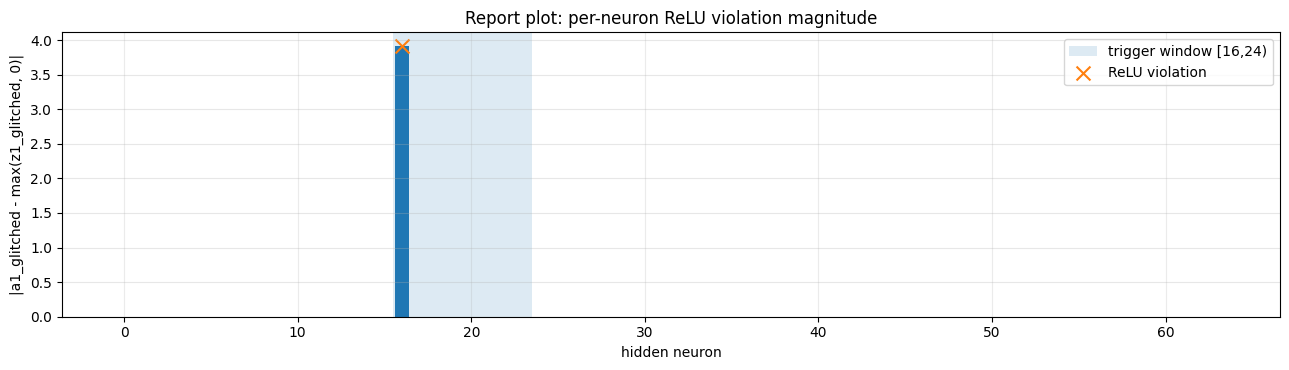

saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\03_relu_violation_map.png


In [41]:

# ---- 3) Report plot: ReLU violation map ----
if len(report_neuron_table):
    # Use full best dataframe for plotting, not only sorted/report subset.
    plot_best_df = report_best_df.sort_values('neuron').copy()
    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.bar(plot_best_df['neuron'], plot_best_df['abs_test_relu_error'])
    ax.axvspan(VALIDATION_TRIGGER_START - 0.5, VALIDATION_TRIGGER_STOP - 0.5, alpha=0.15, label=f'trigger window [{VALIDATION_TRIGGER_START},{VALIDATION_TRIGGER_STOP})')
    if 'violation' in plot_best_df.columns:
        bad_mask = plot_best_df['violation'].astype(bool)
        if bad_mask.any():
            ax.scatter(plot_best_df.loc[bad_mask, 'neuron'], plot_best_df.loc[bad_mask, 'abs_test_relu_error'], s=100, marker='x', label='ReLU violation')
    ax.set_xlabel('hidden neuron')
    ax.set_ylabel('|a1_glitched - max(z1_glitched, 0)|')
    ax.set_title('Report plot: per-neuron ReLU violation magnitude')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(REPORT_DIR / '03_relu_violation_map.png', dpi=220)
    plt.show()
    print('saved:', REPORT_DIR / '03_relu_violation_map.png')
else:
    print('Skipping ReLU violation map: no best neuron table available.')


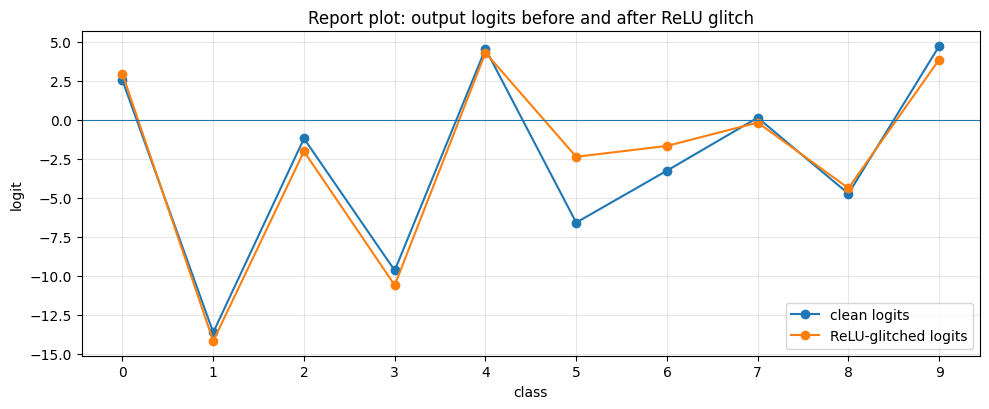

REPORT TABLE 3: Logit changes, sorted by absolute delta


,class,clean_logit,glitched_logit,delta,abs_delta
5,5,-6.587747,-2.368421,4.219326,4.219326
6,6,-3.258457,-1.672673,1.585784,1.585784
3,3,-9.656887,-10.603271,-0.946384,0.946384
9,9,4.729550,3.864743,-0.864807,0.864807
2,2,-1.194577,-2.020119,-0.825542,0.825542
1,1,-13.629911,-14.178698,-0.548786,0.548786
0,0,2.522987,2.935059,0.412072,0.412072
8,8,-4.736228,-4.379904,0.356324,0.356324
7,7,0.136177,-0.172489,-0.308666,0.308666
4,4,4.551976,4.306609,-0.245367,0.245367


saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\04_logits_clean_vs_relu_glitch.png
saved: results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\04_logits_delta_table.csv


In [42]:

# ---- 4) Report plot: logits clean vs glitched ----
if report_clean_logits is not None and report_glitch_logits is not None and len(report_clean_logits) == NN_OUT and len(report_glitch_logits) == NN_OUT:
    classes = np.arange(NN_OUT)
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(classes, report_clean_logits, marker='o', label='clean logits')
    ax.plot(classes, report_glitch_logits, marker='o', label='ReLU-glitched logits')
    ax.axhline(0, lw=0.8)
    ax.set_xticks(classes)
    ax.set_xlabel('class')
    ax.set_ylabel('logit')
    ax.set_title('Report plot: output logits before and after ReLU glitch')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(REPORT_DIR / '04_logits_clean_vs_relu_glitch.png', dpi=220)
    plt.show()

    report_logits_table = pd.DataFrame({
        'class': classes,
        'clean_logit': report_clean_logits,
        'glitched_logit': report_glitch_logits,
        'delta': report_glitch_logits - report_clean_logits,
        'abs_delta': np.abs(report_glitch_logits - report_clean_logits),
    }).sort_values('abs_delta', ascending=False)
    report_logits_table.to_csv(REPORT_DIR / '04_logits_delta_table.csv', index=False)
    print('REPORT TABLE 3: Logit changes, sorted by absolute delta')
    display(report_logits_table)
    print('saved:', REPORT_DIR / '04_logits_clean_vs_relu_glitch.png')
    print('saved:', REPORT_DIR / '04_logits_delta_table.csv')
else:
    print('Skipping logits report plot: clean/glitched logits not available in this session.')


In [43]:

# ---- 5) Final report-ready checklist ----
print('=== REPORT-READY ARTIFACTS ===')
for name in [
    '01_control_vs_glitch_summary.csv',
    '01_control_vs_glitch_summary.png',
    '02_best_neuron_table_top12.csv',
    '02_best_neuron_table_full.csv',
    '03_relu_violation_map.png',
    '04_logits_clean_vs_relu_glitch.png',
    '04_logits_delta_table.csv',
]:
    path = REPORT_DIR / name
    print(('OK   ' if path.exists() else 'MISS ') + str(path))

=== REPORT-READY ARTIFACTS ===
OK   results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\01_control_vs_glitch_summary.csv
OK   results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\01_control_vs_glitch_summary.png
OK   results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\02_best_neuron_table_top12.csv
OK   results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\02_best_neuron_table_full.csv
OK   results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\03_relu_violation_map.png
OK   results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\04_logits_clean_vs_relu_glitch.png
OK   results_relu_only\deep_dive\relu_deep_dive_20260425_154416\report_ready_best_case\04_logits_delta_table.csv

Suggested report sentence:
The no-glitch control produced no ReLU violations, while the targeted clock glitch produced snapshot-backed ReLU viola

In [44]:
# scope.io.hs2 = 'clkgen'
# try: target.dis()
# except Exception: pass
# try: scope.dis()
# except Exception: pass
# print('disconnected')